# FicZon Lead Quality Prediction

 FicZon Inc wants to improve sales effectiveness by predicting lead quality early.
 ## The project goal is
 1) Explore lead data for sales effectiveness.
 2) Build a machine learning model to predict `Lead Category` as `High Potential` or `Low Potential`.

In [1]:
#Importing basic libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Loading the data 
data = pd.read_csv("sales_data.csv", encoding="latin1", sep=';')

# Basic Checks

In [3]:
# Basic check of the dataset
data.head()  

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,NaN,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,NaN,Mode-5,Open
1,14-11-2018 09:22,NaN,Website,XXXXXXX,#VALUE!,Sales-Agent-10,NaN,Mode-5,Open
2,14-11-2018 09:21,NaN,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,NaN,Mode-5,Open
3,14-11-2018 08:46,NaN,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open
4,14-11-2018 07:34,NaN,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open


#### --> We see the features of head columns
#### --> There are 9 features present Created, Product_ID, Source, Mobile, EMAIL, Sale_Agent, Location, Delivery_Mode, Status

In [4]:
data.tail()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
7417,28-04-2018 09:45,9.0,Call,NaN,aXXXXXXX@gmail.com,Sales-Agent-6,Mumbai,Mode-4,LOST
7418,28-04-2018 09:43,15.0,Call,NaN,#VALUE!,Sales-Agent-12,Other Locations,Mode-5,LOST
7419,28-04-2018 09:20,5.0,Live Chat-Direct,NaN,sXXXXXXX@gmail.com,Sales-Agent-11,Bangalore,Mode-1,Not Responding
7420,28-04-2018 08:04,21.0,CRM form,NaN,YXXXXXXX@gmail.com,Sales-Agent-4,Other Locations,Mode-1,Just Enquiry
7421,28-04-2018 07:54,25.0,Website,NaN,cXXXXXXX@gmail.com,Sales-Agent-3,Chennai,Mode-1,CONVERTED


#### --> Seeing End of the dataset how many rows Present 
#### --> There are 7422 is last row in the datase

In [5]:
data.info() # checking the data information like 
# how many rows and columns present
# Any missing values and the Datatyes of the column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7422 entries, 0 to 7421
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Created        7422 non-null   object 
 1   Product_ID     7364 non-null   float64
 2   Source         7405 non-null   object 
 3   Mobile         5612 non-null   object 
 4   EMAIL          7422 non-null   object 
 5   Sales_Agent    7399 non-null   object 
 6   Location       7364 non-null   object 
 7   Delivery_Mode  7422 non-null   object 
 8   Status         7422 non-null   object 
dtypes: float64(1), object(8)
memory usage: 522.0+ KB


#### --> Here we see features data types and  Non-Null Count
#### --> We see the Most of data types is 'Object', and one Float data type
#### --> NON-Null Count the diffent numbers of each feature means there is Nulls in the data

In [6]:
data.describe() 

,Product_ID
count,7364.000000
mean,15.947311
std,6.072937
min,0.000000
25%,12.000000
50%,18.000000
75%,19.000000
max,28.000000


#### --> There is one Num feature we see statistical presentation of Numerical data where we see min,max,mean,count,std

In [7]:
data.describe(include=['object'])

,Created,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
count,7422,7405,5612,7422,7399,7364,7422,7422
unique,6752,25,486,883,12,17,5,11
top,27-09-2018 11:00,Call,XXXXXXX,#VALUE!,Sales-Agent-4,Other Locations,Mode-5,Junk Lead
freq,4,2547,222,1701,1500,2500,2975,1536


#### --> we see statistical presentation of categorical data there count , Unique, Top, Freq.

In [8]:
data.isnull().sum() 

Created             0
Product_ID         58
Source             17
Mobile           1810
EMAIL               0
Sales_Agent        23
Location           58
Delivery_Mode       0
Status              0
dtype: int64

#### --> we find nulls and Missing values in  the data

In [9]:
data.duplicated().sum()

np.int64(2)

#### --> Find the Duplicates in the data

In [10]:
data.columns

Index(['Created', 'Product_ID', 'Source', 'Mobile', 'EMAIL', 'Sales_Agent',
       'Location', 'Delivery_Mode', 'Status'],
      dtype='object')

#### --> The Columns and column Names of the dataset

In [11]:
data.shape 

(7422, 9)

#### --> Shape of the dataset like 9 columns and 7422 rows 

# Domain Analysis

### Created
* Contains lead creation timestamp in `dd-mm-yyyy hh:mm` format.
* Best used as derived features: day, month, year, hour, minute, weekday/weekend, business vs non-business hours.
* Helps identify seasonality and peak lead capture times.
* Needs parsing to datetime before modeling; raw string is not directly usable.
* After extraction, the original column can be dropped if only derived parts are used.

### Product_ID
- Represents a product category, not a numeric measure.
- Very skewed: `18`, `15`, `19`, `9`, `27`, `5` provide most of the data.
- Many product IDs are rare, so group low-frequency IDs into `Other` to avoid overfitting.
- Use categorical encoding (target/count encoding) rather than treating as continuous.
- Signals which product lines generate the most leads.

### Source
- Captures lead origin channel.
- Highly concentrated: `Call`, `Live Chat-Direct`, `Website` are the top sources.
- Long tail of small sources means you should group infrequent channels.
- Important for channel performance analysis and model bias.
- Reflects marketing/sales channel effectiveness.

### Mobile
- Contact information, not a predictive feature in most models.
- Likely sensitive / PII, so drop or mask unless doing contact-quality analysis.
- Can be used only for deduplication or data quality checks.
- Not suitable for direct modeling due to formatting and privacy issues.

### EMAIL
- Another contact field, also not predictive by itself.
- Contains invalid values like `#VALUE!`, so it needs cleaning if used.
- Better treated as data quality or identifier information, not a feature.
- Should usually be excluded from the prediction model.

### Sales_Agent
- Categorical and skewed: a few agents handle the majority of leads.
- Top agents like `Sales-Agent-4`, `Sales-Agent-11`, `Sales-Agent-5` dominate.
- Good for capturing agent-level performance or assignment patterns.
- Rare agents may have too little data, so consider grouping or encoding carefully.
- Can introduce leakage if the same agent always handles a certain status.

### Location
- Geographic source of the lead.
- Dominated by `Other Locations` and `Bangalore`, with a few secondary cities.
- Many small locations exist, so group minor ones to reduce sparsity.
- Useful for market segmentation and regional performance.
- Location imbalance may reflect where business is concentrated.

### Delivery_Mode
- Categorical mode of delivery/interaction.
- Strongly skewed: `Mode-5`, `Mode-1`, `Mode-3` cover most leads.
- Rare modes like `Mode-2` and `Mode-4` should be grouped or treated as low-frequency.
- Useful for understanding preferred communication channels.
- Likely a meaningful categorical predictor if it correlates with lead quality.

### Status
- Represents lead outcome/state.
- Many statuses, with `Junk Lead`, `Not Responding`, `CONVERTED`, `Just Enquiry` as top values.
- Can be mapped to binary `Lead_Category` (`High Potential` / `Low Potential`).
- Key target-related variable for lead quality modeling.
- Important to check and clean for inconsistent casing or missing categories.


# Creating The Target Variable

In [12]:
# Check Status
data.Status.value_counts()

Status
Junk Lead               1536
Not Responding          1129
CONVERTED                834
Just Enquiry             760
Potential                708
Long Term                646
In Progress Positive     643
In Progress Negative     626
LOST                     440
Open                      82
converted                 18
Name: count, dtype: int64

In [13]:
# change the same data into one
data['Status'] = data['Status'].replace('converted', 'CONVERTED')

In [14]:
# Check again
data.Status.value_counts()

Status
Junk Lead               1536
Not Responding          1129
CONVERTED                852
Just Enquiry             760
Potential                708
Long Term                646
In Progress Positive     643
In Progress Negative     626
LOST                     440
Open                      82
Name: count, dtype: int64

In [15]:
# Create new Target using Status
status_to_cat = {
    'CONVERTED': 'High Potential',
    'In Progress Positive': 'Low Potential',
    'Potential': 'Low Potential',
    'Long Term': 'Low Potential',
    'Open': 'Low Potential',
    'Not Responding': 'Low Potential',
    'Just Enquiry': 'Low Potential',
    'Junk Lead': 'Low Potential',
    'In Progress Negative': 'Low Potential',
    'LOST': 'Low Potential'}

data['Status'] = data['Status'].astype(str).str.strip()
data['Lead_Category'] = data['Status'].map(status_to_cat)

In [16]:
# Check all data map correctly
data.Lead_Category.isna().sum()

np.int64(0)

In [17]:
# Data Head
data.head()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status,Lead_Category
0,14-11-2018 10:05,NaN,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,NaN,Mode-5,Open,Low Potential
1,14-11-2018 09:22,NaN,Website,XXXXXXX,#VALUE!,Sales-Agent-10,NaN,Mode-5,Open,Low Potential
2,14-11-2018 09:21,NaN,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,NaN,Mode-5,Open,Low Potential
3,14-11-2018 08:46,NaN,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open,Low Potential
4,14-11-2018 07:34,NaN,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open,Low Potential


In [18]:
# Target count 
data.Lead_Category.value_counts()

Lead_Category
Low Potential     6570
High Potential     852
Name: count, dtype: int64

In [19]:
# Separate the Created feature into  Day, Week, Month, Hour
data['Created'] = pd.to_datetime(data['Created'], dayfirst=True, errors='coerce')
data['Created_Day'] = data['Created'].dt.day
data['Month']       = data['Created'].dt.month
data['Day_Week']    = data['Created'].dt.weekday   #  0 = Monday, 6 = Sunday
data['Hour']        = data['Created'].dt.hour

In [20]:
# Drop Created Feature
data.drop(columns=['Created'], inplace=True)

In [21]:
# Check Data Columns
data.columns

Index(['Product_ID', 'Source', 'Mobile', 'EMAIL', 'Sales_Agent', 'Location',
       'Delivery_Mode', 'Status', 'Lead_Category', 'Created_Day', 'Month',
       'Day_Week', 'Hour'],
      dtype='object')

# Using Regex on Mobile, EMAIL to Valid Data

In [22]:
# Check valid mobile (10-digit numbers)
data['mobile_clean'] = data['Mobile'].str.replace(r'\D', '', regex=True)
data['valid_mobile'] = data['mobile_clean'].apply(lambda x: 1 if pd.notna(x) and len(str(x)) == 10 else 0)

# Check valid email
data['valid_email'] = data['EMAIL'].str.contains(r'^[\w\.-]+@[\w\.-]+\.\w+$', na=False, regex=True).astype(int)

print(f"Valid mobile numbers : {data['valid_mobile'].sum()} ({data['valid_mobile'].mean()*100:.1f}%)")
print(f"Valid email addresses: {data['valid_email'].sum()} ({data['valid_email'].mean()*100:.1f}%)")

Valid mobile numbers : 1 (0.0%)
Valid email addresses: 4841 (65.2%)


In [23]:
data.head()

,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status,Lead_Category,Created_Day,Month,Day_Week,Hour,mobile_clean,valid_mobile,valid_email
0,NaN,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,NaN,Mode-5,Open,Low Potential,14,11,2,10,984,0,1
1,NaN,Website,XXXXXXX,#VALUE!,Sales-Agent-10,NaN,Mode-5,Open,Low Potential,14,11,2,9,,0,0
2,NaN,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,NaN,Mode-5,Open,Low Potential,14,11,2,9,,0,1
3,NaN,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open,Low Potential,14,11,2,8,,0,1
4,NaN,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open,Low Potential,14,11,2,7,,0,1


In [24]:
#Mobile count
data.valid_mobile.value_counts()

valid_mobile
0    7421
1       1
Name: count, dtype: int64

In [25]:
# Email count
data.valid_email.value_counts()

valid_email
1    4841
0    2581
Name: count, dtype: int64

In [26]:
# Drop Mobile_clean
data.drop(columns=['mobile_clean'], inplace=True)

In [27]:
# Check Data Head
data.head()

,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status,Lead_Category,Created_Day,Month,Day_Week,Hour,valid_mobile,valid_email
0,NaN,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,NaN,Mode-5,Open,Low Potential,14,11,2,10,0,1
1,NaN,Website,XXXXXXX,#VALUE!,Sales-Agent-10,NaN,Mode-5,Open,Low Potential,14,11,2,9,0,0
2,NaN,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,NaN,Mode-5,Open,Low Potential,14,11,2,9,0,1
3,NaN,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open,Low Potential,14,11,2,8,0,1
4,NaN,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open,Low Potential,14,11,2,7,0,1


# EDA

# Uni-Variant Analysis

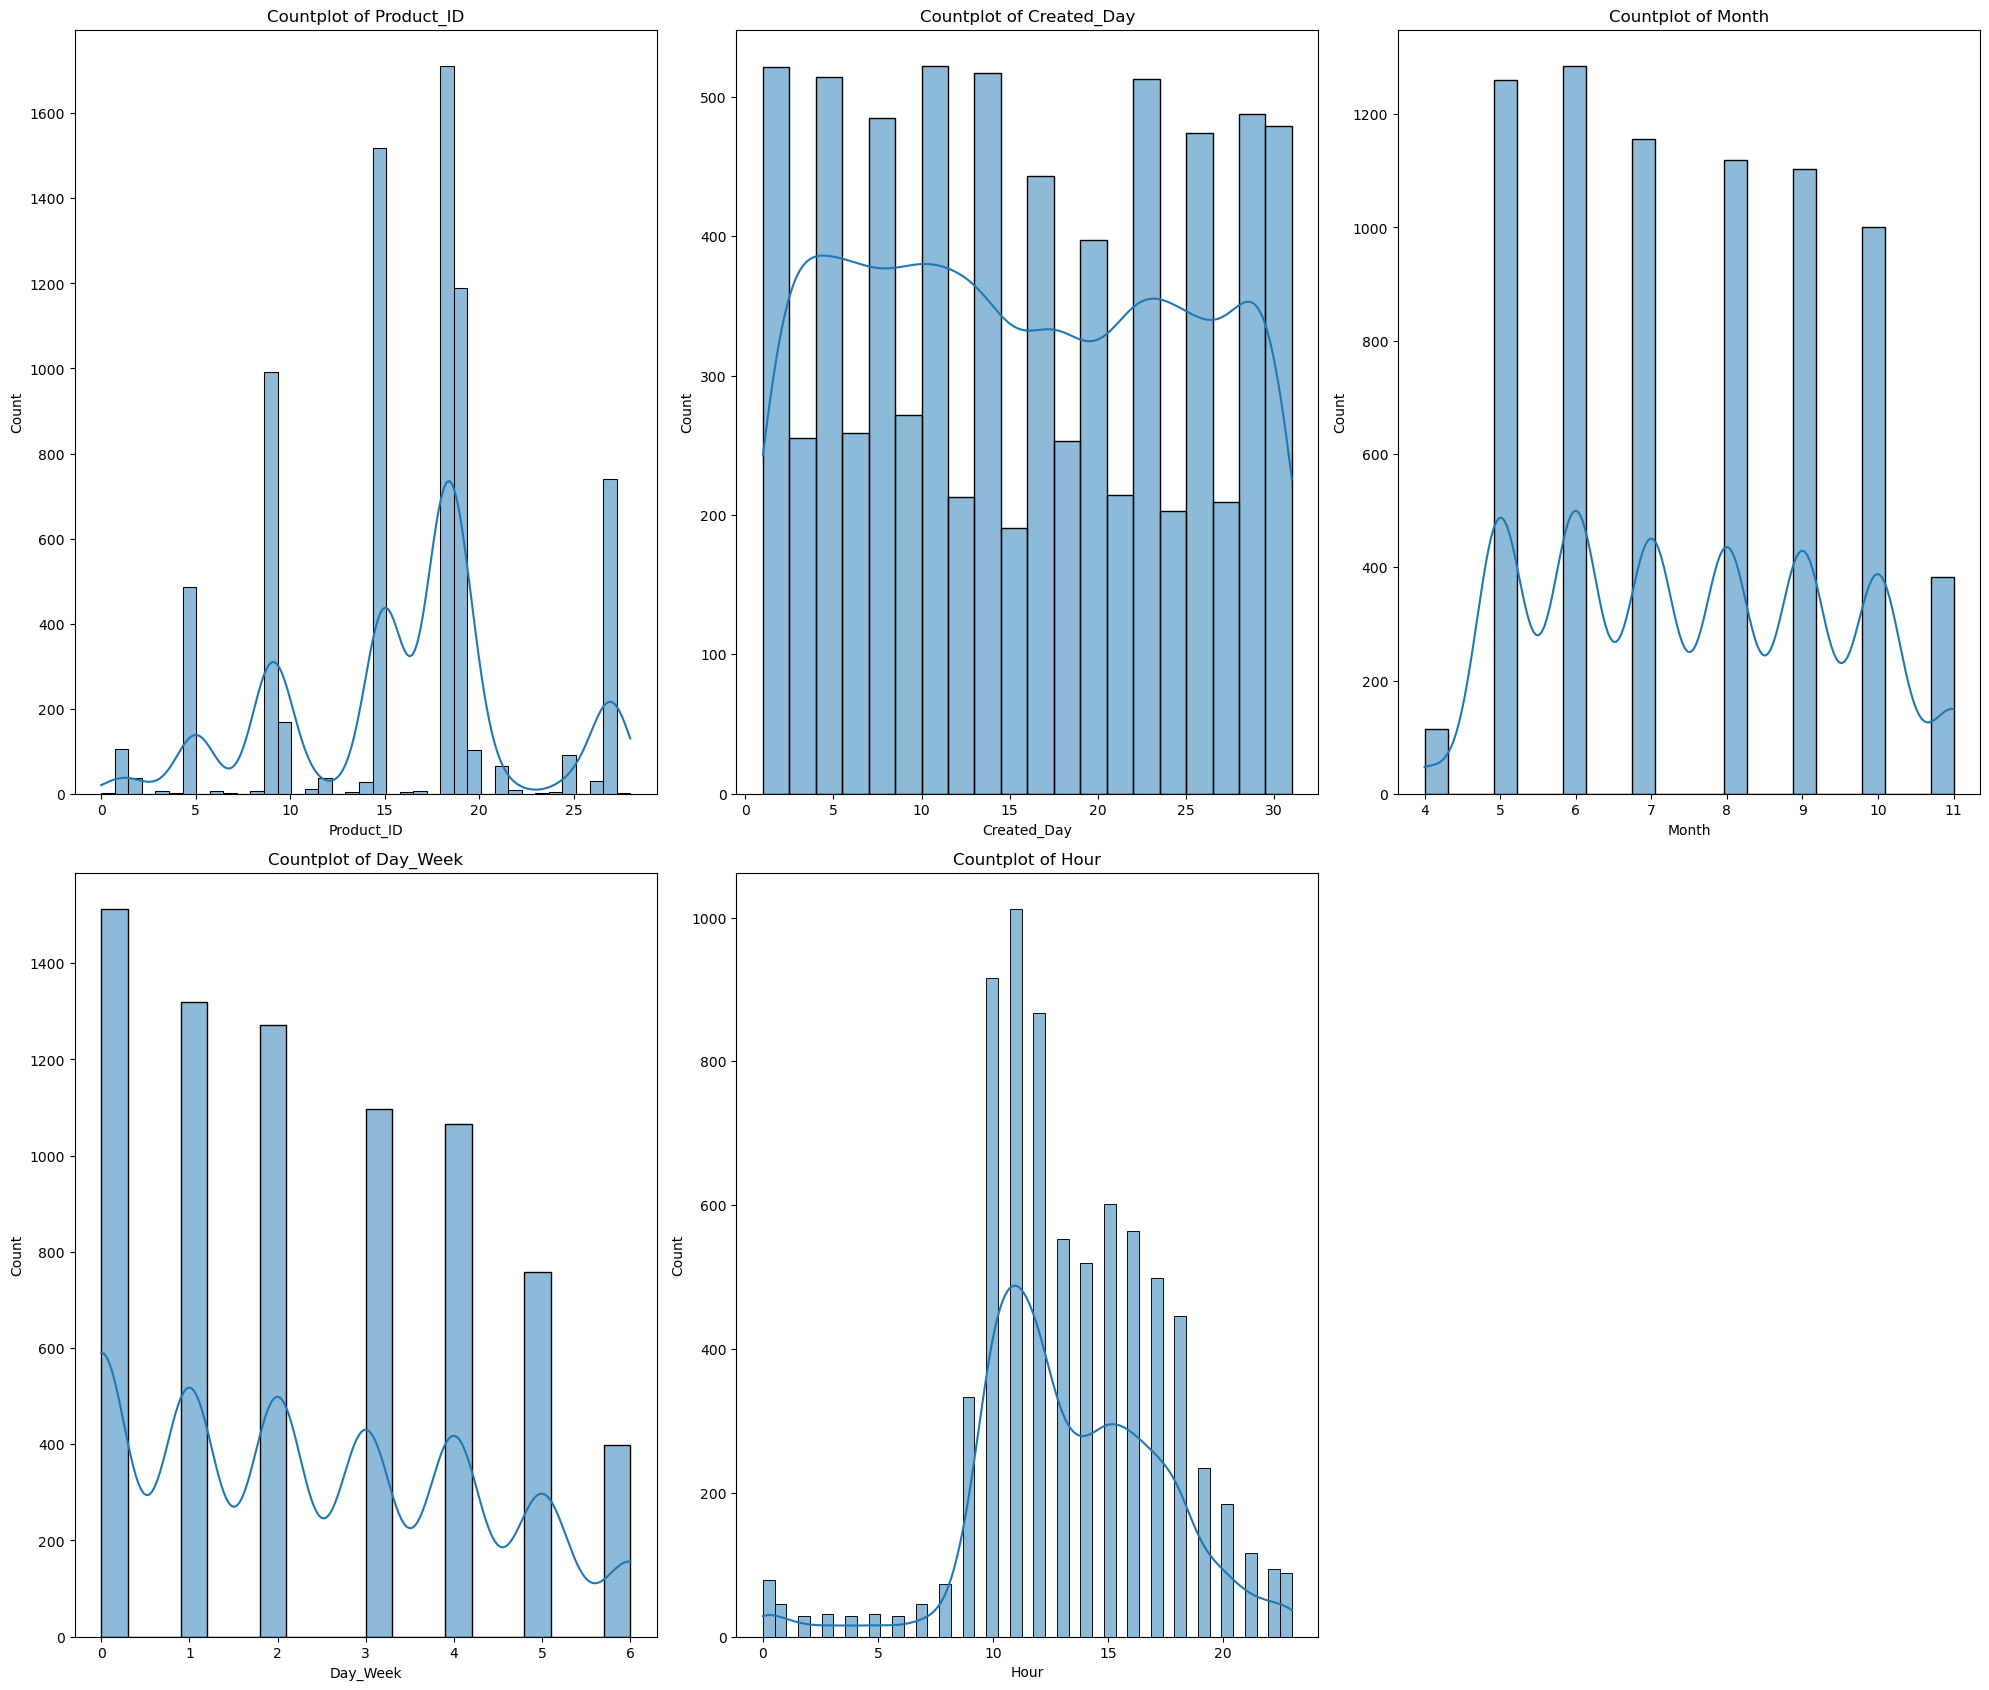

In [28]:
# Graph for Numerical data
data_num = ['Product_ID', 'Created_Day', 'Month','Day_Week', 'Hour']
 
plt.figure(figsize=(20,25), facecolor='white')
plot_number = 1

for col in data_num:
    if plot_number <= 10:
        ax = plt.subplot(3,3, plot_number)
        sns.histplot(data=data, x=col, kde= True)
        plt.xticks(rotation=0)
        plt.title(f"Countplot of {col}")
        plot_number += 1

plt.tight_layout()
plt.show()


# Insights of Numerica data

### Product_ID 
* Certain product IDs (like around 10, 15, and 20) are far more popular, showing concentrated demand.

* The distribution is uneven, suggesting a few products dominate sales while others are less frequent.

 ### Created_Day 
* Counts are relatively consistent across days, meaning product creation or activity is evenly spread.

* No single day stands out, which could indicate a stable workflow or balanced customer engagement.

### Month
* Activity peaks between months 5–9, showing a seasonal trend (possibly mid-year demand).

* Lower counts in other months suggest off-season periods where engagement or sales dip.

### Day_Week 
* Higher counts at the start of the week (likely Monday/Tuesday), indicating strong early-week activity.

* Decline toward the weekend suggests reduced engagement or fewer transactions later in the week.

### Hour 
* Clear peak in mid-morning to early afternoon, showing prime activity hours.

* Lower counts at night and late evening suggest customers or users are less active outside working hours.

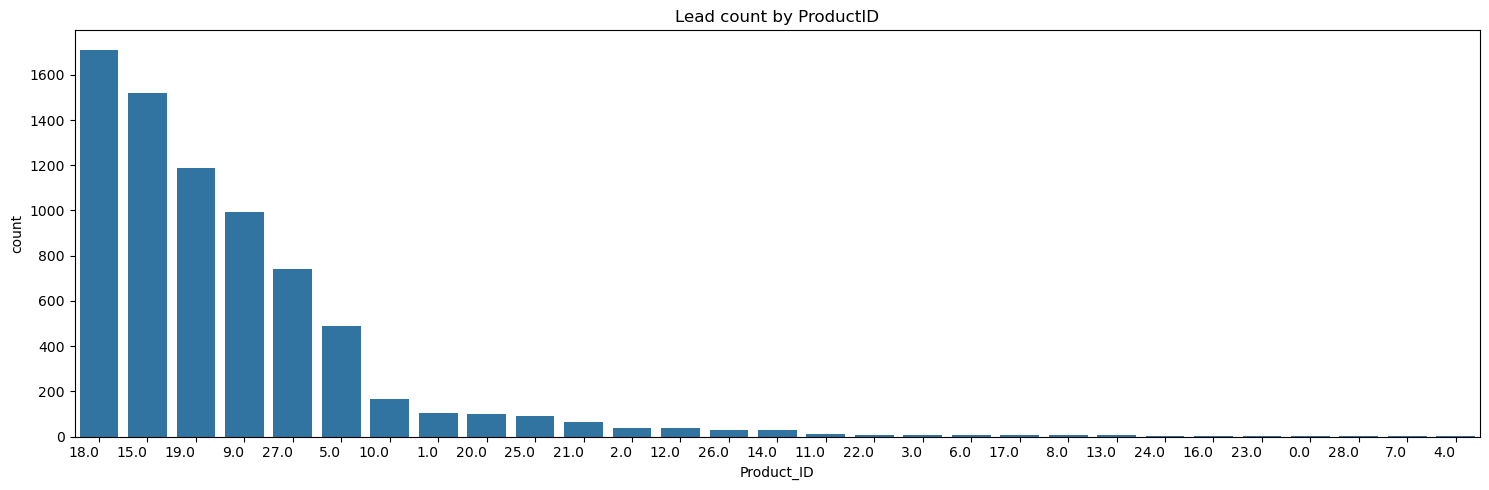

In [29]:
plt.figure(figsize=(15,5))
sns.countplot(data=data, x='Product_ID', order=data['Product_ID'].value_counts().index)
plt.xticks(rotation=0, ha='right')
plt.title('Lead count by ProductID')
plt.tight_layout()
plt.show()

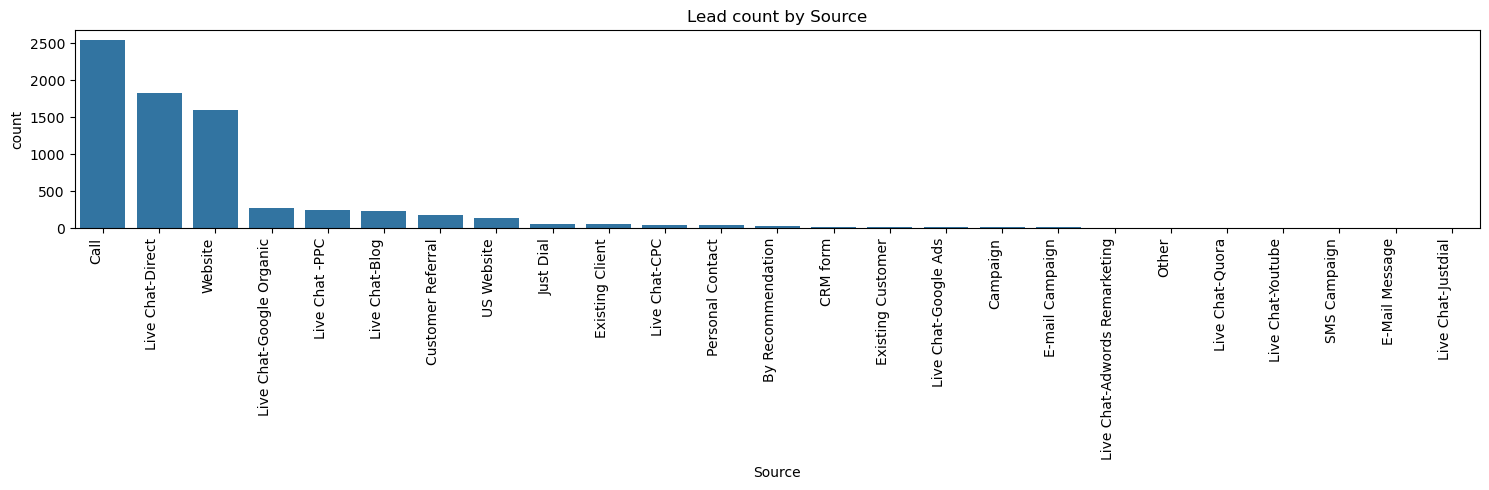

In [30]:
plt.figure(figsize=(15,5))
sns.countplot(data=data, x='Source', order=data['Source'].value_counts().index)
plt.xticks(rotation=90, ha='right')
plt.title('Lead count by Source')
plt.tight_layout()
plt.show()

#### --> Both 'Product_ID and Source' have some data have Max counts.
#### --> Some  data low counts or No counts means low frequency need to Correct it.

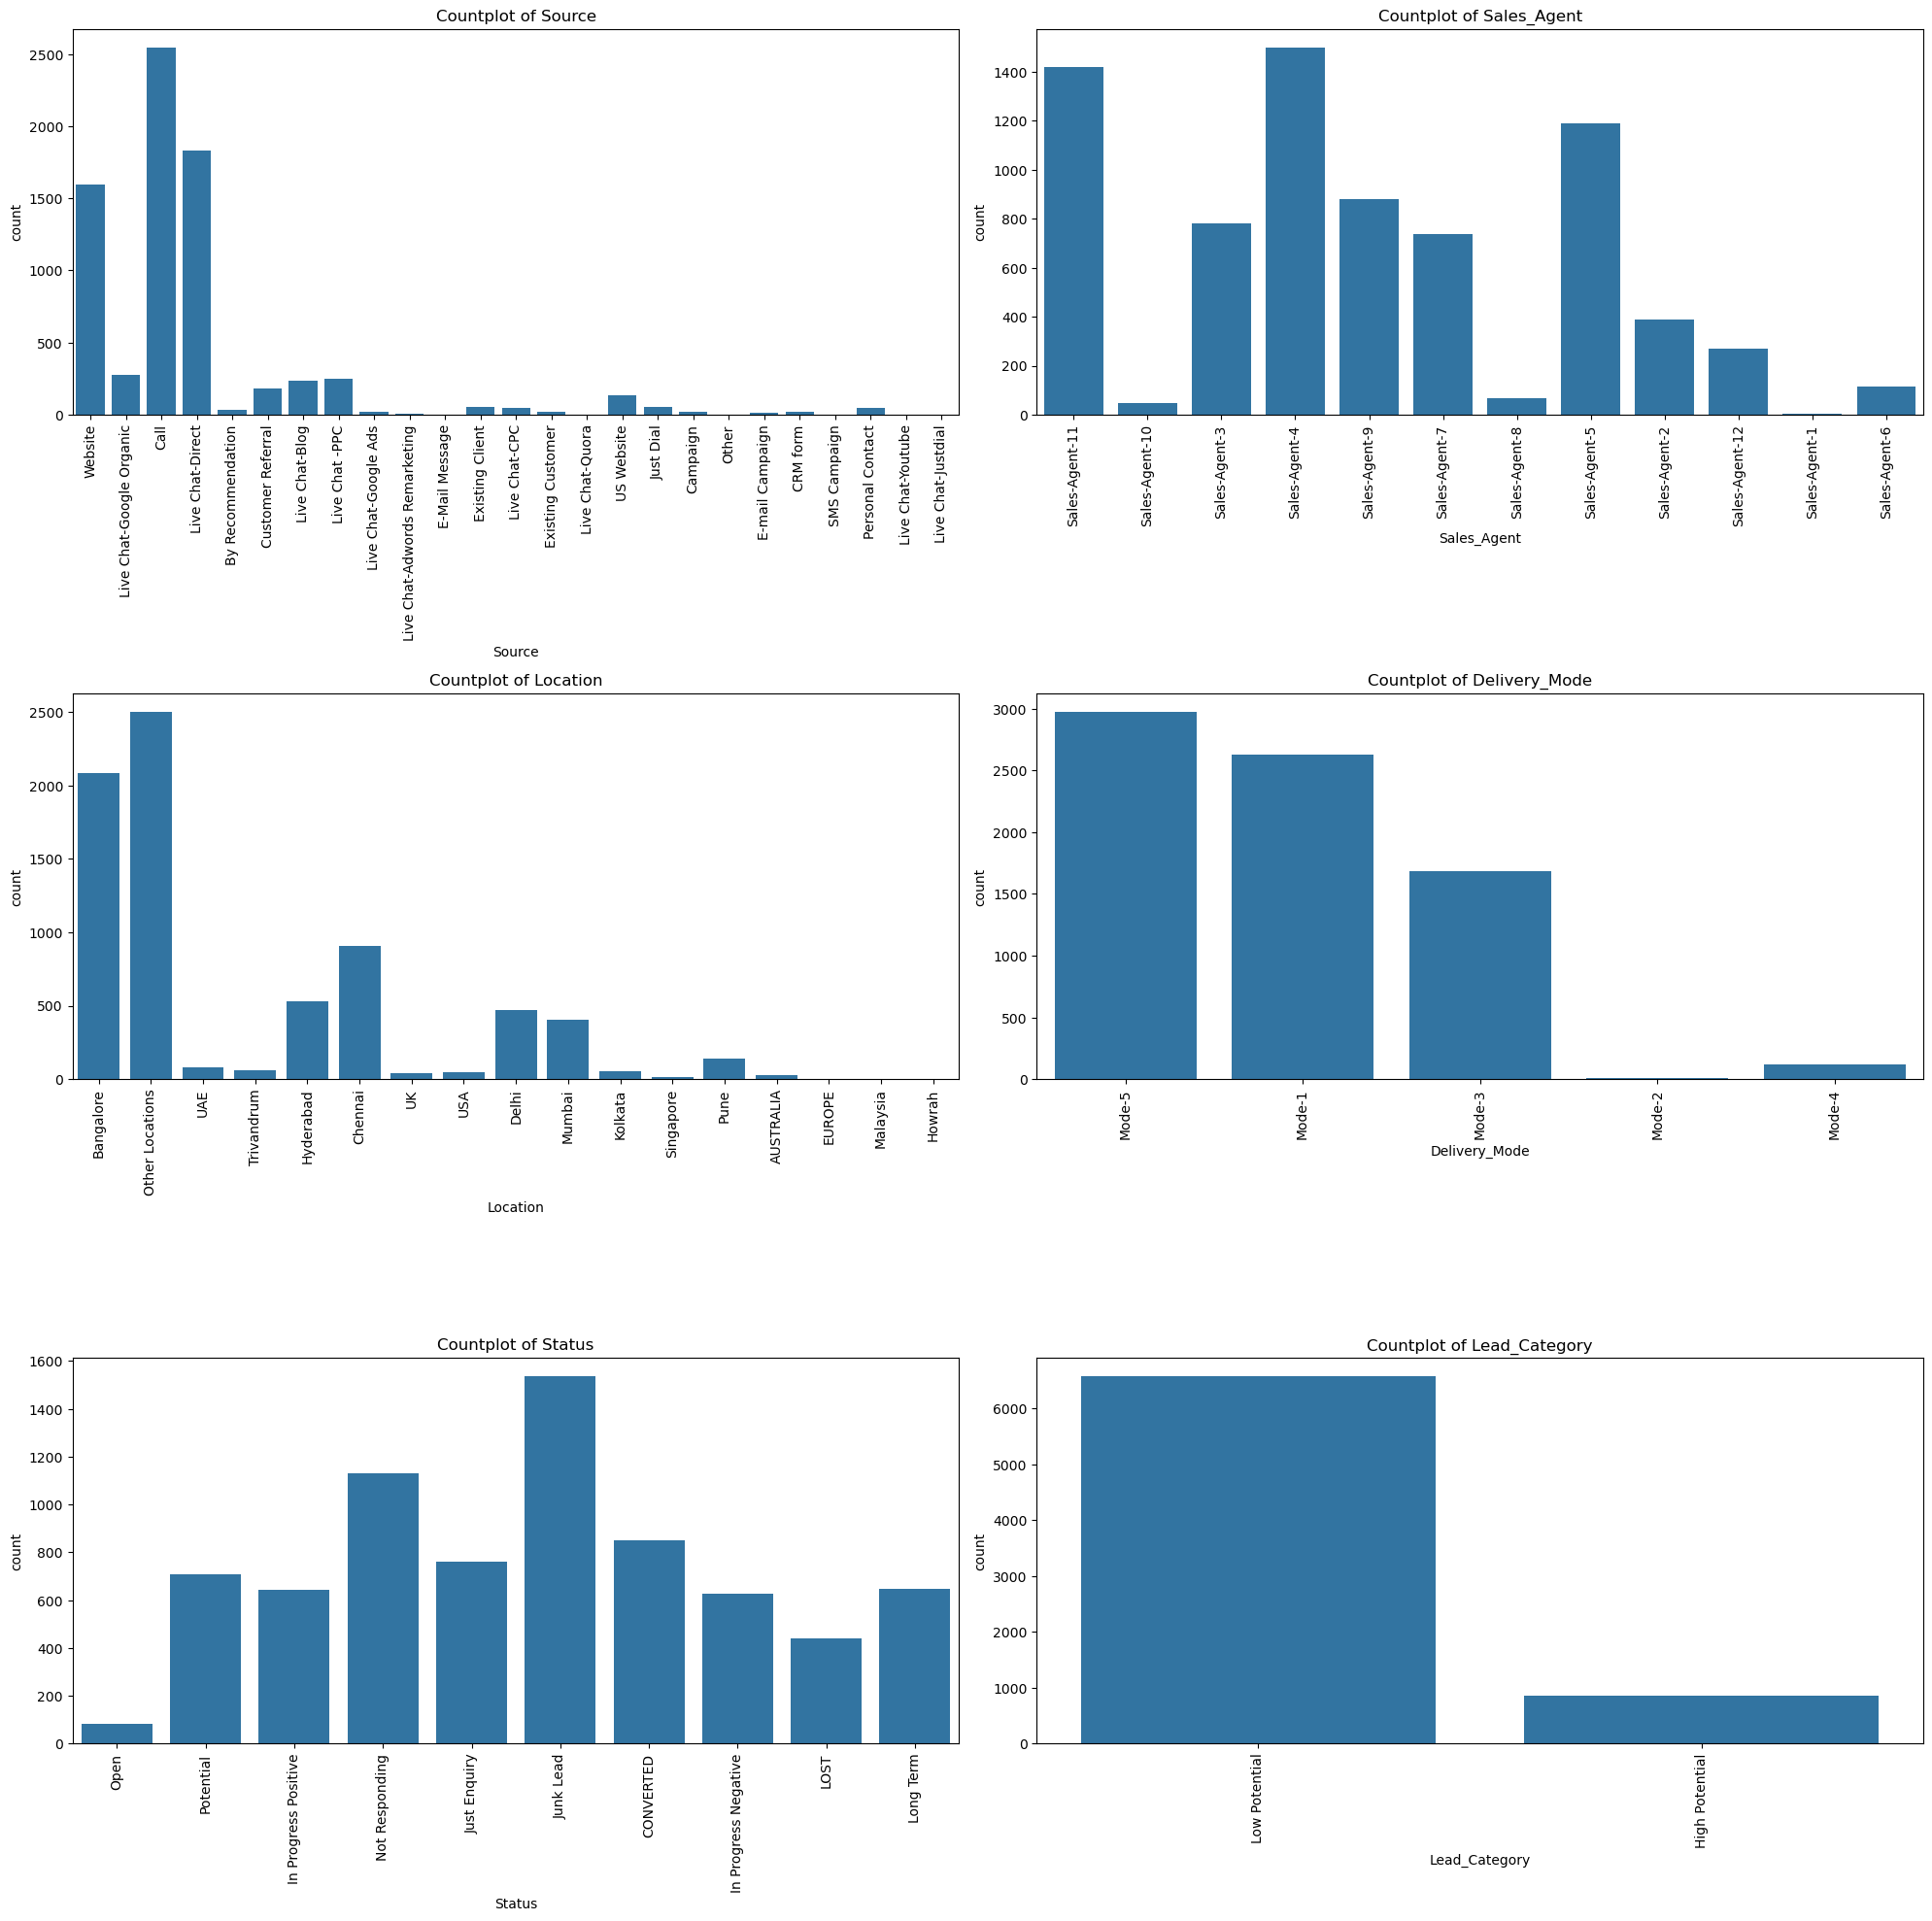

In [31]:
# Graph for Categorical data
data_cat = ['Source', 'Sales_Agent', 'Location', 'Delivery_Mode', 'Status','Lead_Category'] 

plt.figure(figsize=(20,25), facecolor='white')
plot_number = 1

for col in data_cat:
    if plot_number <= 10:
        ax = plt.subplot(4,2, plot_number)
        sns.countplot(data=data, x=col)
        plt.xticks(rotation=90)
        plt.title(f"Countplot of {col}")
        plot_number += 1

plt.tight_layout()
plt.show()


### Lead Sources & Channels

* The Website dominates as the primary source, far ahead of campaigns or references.

* Multi-channel combinations (Google Ads, FB, Live Chat) exist but contribute far less, showing reliance on a single strong funnel.

### Sales Agents Performance

* SalesAgent1 and SalesAgent6 handle the largest share of leads, suggesting workload concentration.

* Other agents have moderate to low counts, which may indicate uneven distribution or varying effectiveness.

### Location

* Bangalore is the clear hub, with significantly higher counts than other cities or countries.

* Locations like UAE, USA, and Europe show smaller but notable presence, hinting at international reach.

### Delivery Modes

* Mode-5 is overwhelmingly dominant, suggesting either customer preference or operational efficiency.

* Other modes are used far less, which could mean limited flexibility or strong standardization.

### Lead Status

* A large portion of leads fall under “Just Looked”, meaning many inquiries don’t progress.

* Converted leads are relatively fewer, highlighting a potential gap in conversion strategy.

### Lead Category

* Low Potential leads vastly outnumber High Potential, showing that most inquiries may not be strong prospects.

* This imbalance suggests the need for better targeting or qualification of leads

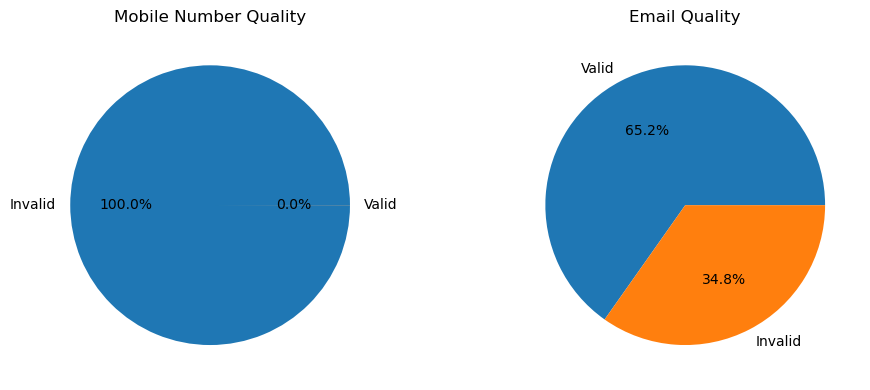

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
data['valid_mobile'].value_counts().rename({0:'Invalid', 1:'Valid'}).plot(kind='pie', autopct='%1.1f%%', ax=axes[0])
axes[0].set_title('Mobile Number Quality')
axes[0].set_ylabel('')

data['valid_email'].value_counts().rename({0:'Invalid', 1:'Valid'}).plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
axes[1].set_title('Email Quality')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

### Mobile, EMAIL
* Mobile all invalid so we drop it
* We Keep Email there is some Valid data in Email

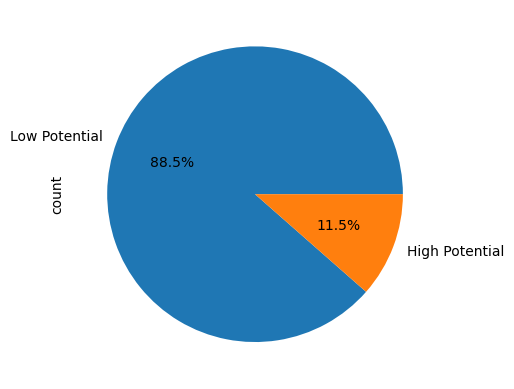

In [33]:
data['Lead_Category'].value_counts().plot.pie(autopct='%1.1f%%')
plt.show()

## Lead_Category
* The precentage of target data 88% is Low Potential and just 11% is High Potential

In [34]:
data.columns

Index(['Product_ID', 'Source', 'Mobile', 'EMAIL', 'Sales_Agent', 'Location',
       'Delivery_Mode', 'Status', 'Lead_Category', 'Created_Day', 'Month',
       'Day_Week', 'Hour', 'valid_mobile', 'valid_email'],
      dtype='object')

# Bi-Variant Analysis

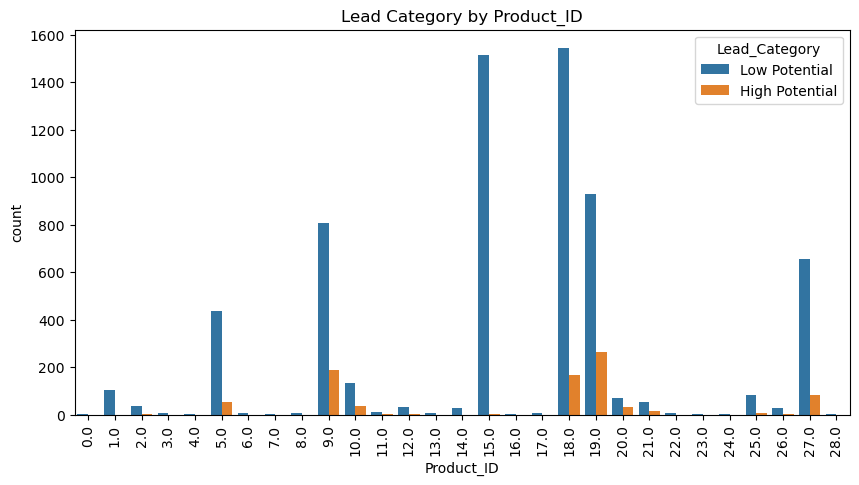

In [35]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Product_ID', hue='Lead_Category', data=data)
plt.title('Lead Category by Product_ID')
plt.xticks(rotation=90)
plt.show()

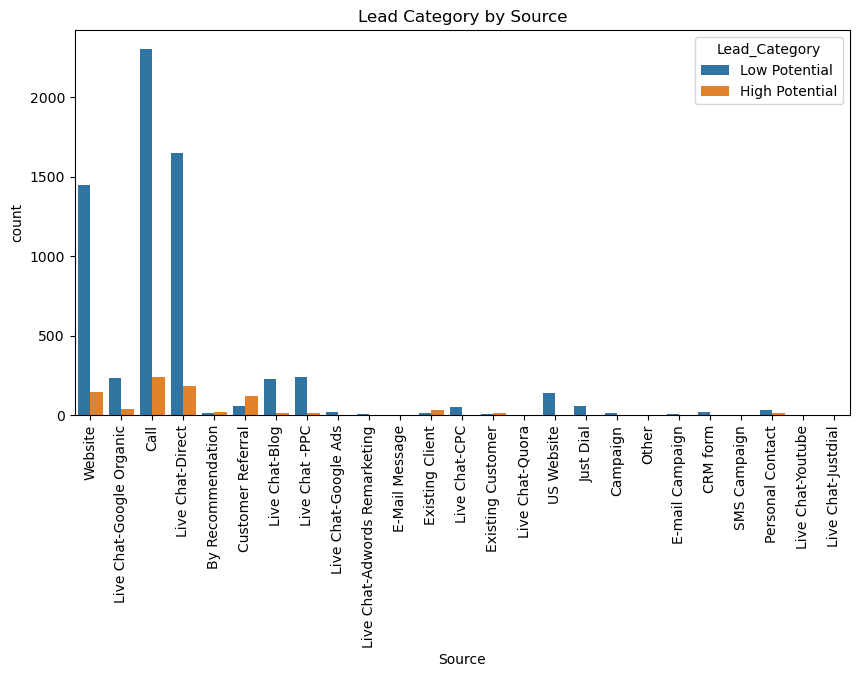

In [36]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Source', hue='Lead_Category', data=data)
plt.title('Lead Category by Source')
plt.xticks(rotation=90)
plt.show()

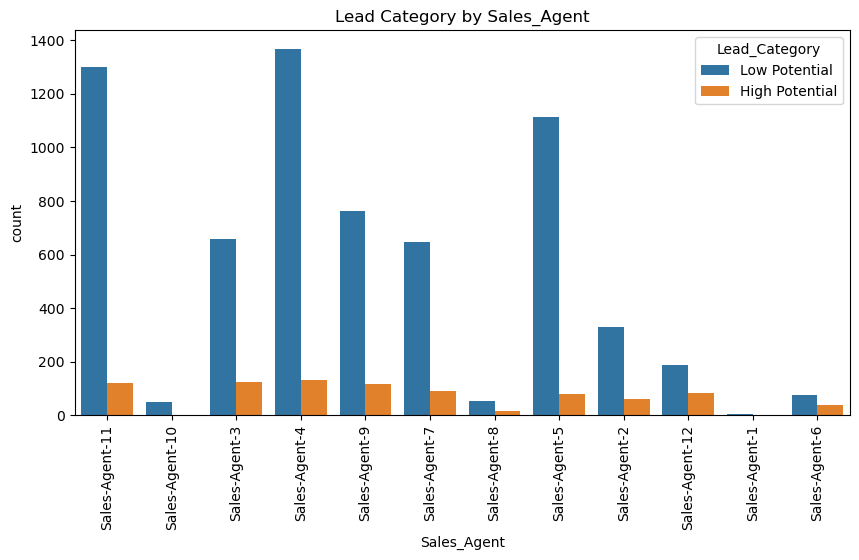

In [37]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Sales_Agent', hue='Lead_Category', data=data)
plt.title('Lead Category by Sales_Agent')
plt.xticks(rotation=90)
plt.show()

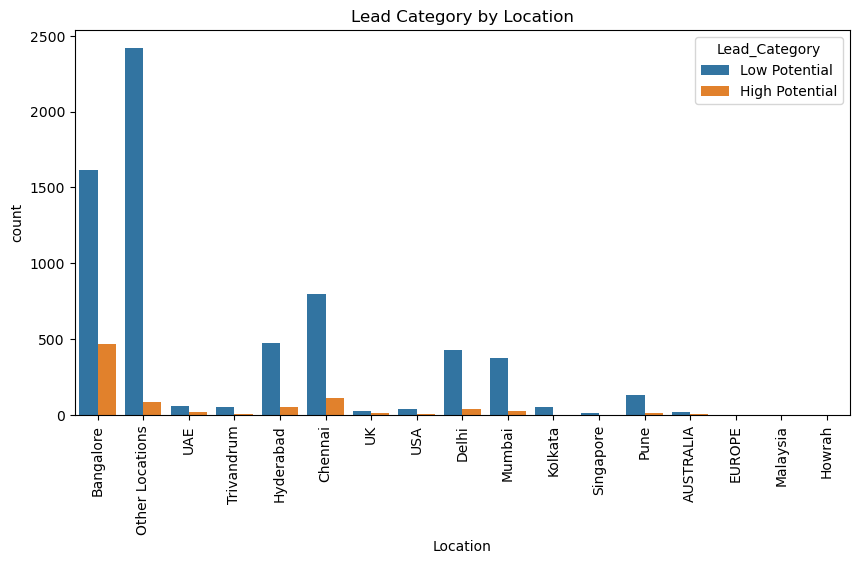

In [38]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Location', hue='Lead_Category', data=data)
plt.title('Lead Category by Location')
plt.xticks(rotation=90)
plt.show()

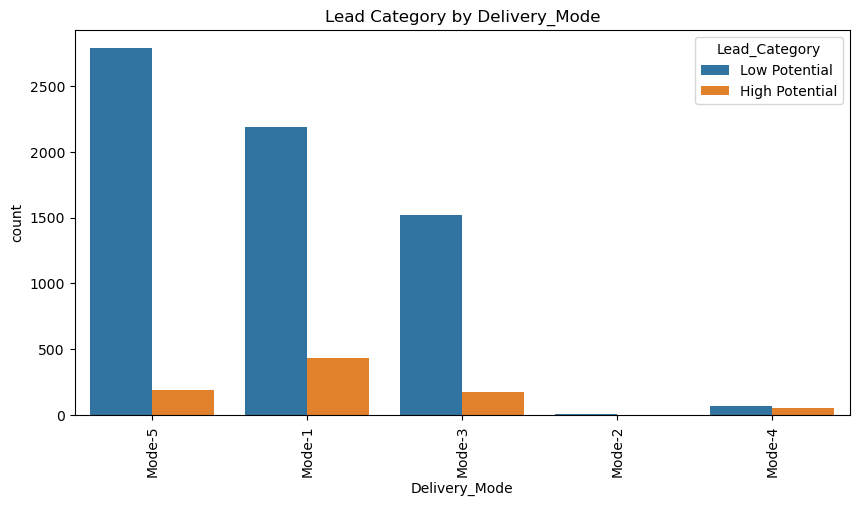

In [39]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Delivery_Mode', hue='Lead_Category', data=data)
plt.title('Lead Category by Delivery_Mode')
plt.xticks(rotation=90)
plt.show()

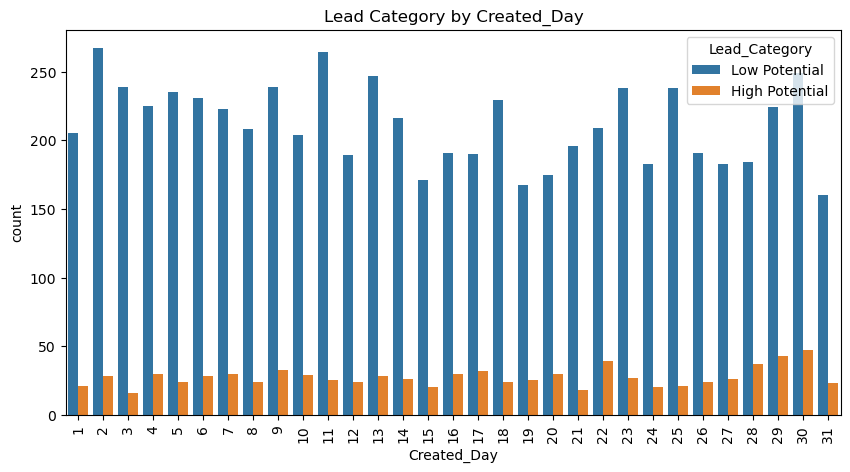

In [40]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Created_Day', hue='Lead_Category', data=data)
plt.title('Lead Category by Created_Day')
plt.xticks(rotation=90)
plt.show()

# Insights of Bi Variant Analysis data

### Lead Category by Product_ID
* Certain products (like IDs 9, 15, 17, 18) attract many leads, but most are low potential, showing weak conversion prospects.

* Few products generate balanced high-potential leads, suggesting focus areas for targeted sales.

### Lead Category by Source
* Website and Call dominate lead generation, but mostly with low potential leads.

* Alternative sources (campaigns, referrals, live chat) contribute fewer leads but may hold better quality opportunities.

### Lead Category by Sales_Agent
* Sales-Agent 4 and Sales-Agent 11 handle the largest share of low potential leads, indicating workload concentration.

* High potential leads are scarce across all agents, pointing to a need for improved qualification or training.

### Lead Category by Location
* Bangalore and Other Locations are the biggest lead hubs, with Bangalore showing a healthier mix of low and high potential.

* International regions (UAE, USA, Europe) generate fewer leads, but could be growth markets if nurtured.

### Lead Category by Delivery_Mode
* Mode-5 dominates, but heavily with low potential leads, suggesting inefficiency in this delivery approach.

* Other modes (Mode-1, Mode-3) show smaller but more balanced distributions, hinting at possible optimization.

### Lead Category by Created_Day
* Across all days, low potential leads consistently outweigh high potential, showing a systemic issue in lead quality.

* No single day stands out for high potential, meaning timing isn’t the main driver—lead sourcing strategy is.

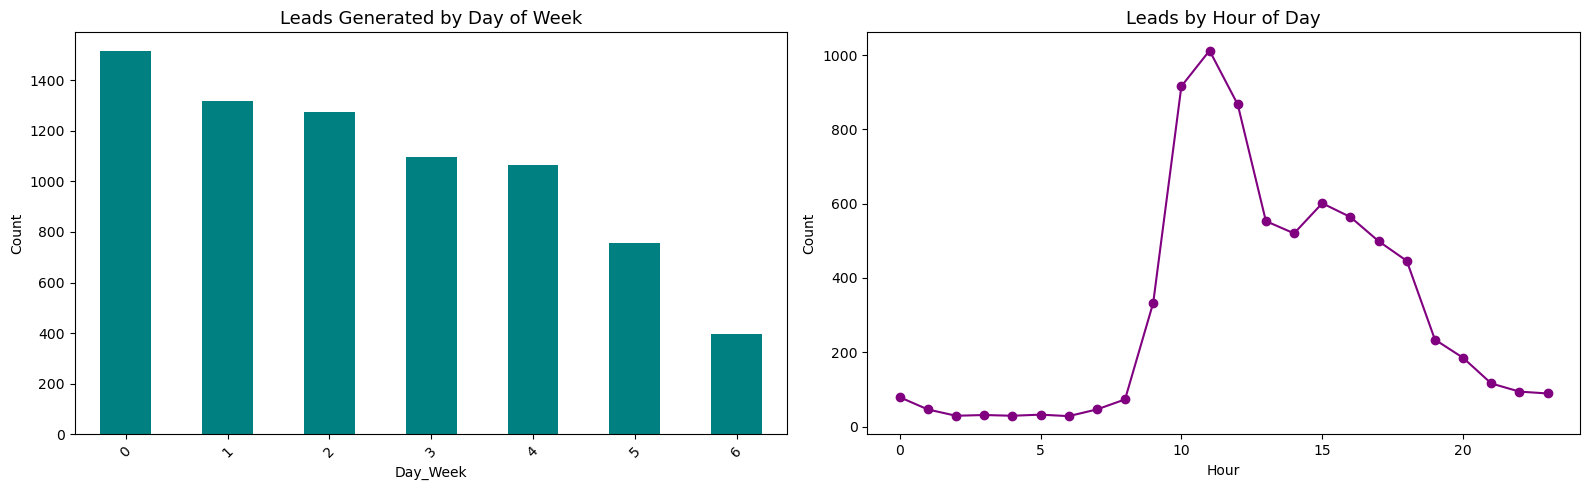

In [41]:
# Time Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

leads_by_day = data.groupby('Day_Week').size()
leads_by_day.plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Leads Generated by Day of Week', fontsize=13)
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

data.groupby('Hour').size().plot(kind='line', ax=axes[1], marker='o', color='purple')
axes[1].set_title('Leads by Hour of Day', fontsize=13)
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Day-of-Week Trends

* Lead generation is strongest at the start of the week (Day 0–2), gradually declining toward the weekend.

* The lowest activity is on Day 6, showing weekends are least productive for lead inflow.

## Hourly Patterns

* Leads spike sharply around 9–10 AM, crossing 1000 counts, which marks the prime window of engagement.

* After late morning, activity declines but remains moderate until early evening (13–17 hours), then tapers off.

* Early weekdays and mid-morning hours are the most effective periods for campaigns, outreach, or customer engagement.

* Resources (sales agents, marketing pushes) should be concentrated during these peak times.

* The drop-off after midweek and evenings suggests untapped potential—strategies like weekend promotions or evening campaigns could balance the distribution.

# Data Preprocessing/ Feature Engneering

In [42]:
#Copying Original data to New Variable for Preprocessing steps
data_pre = data.copy()

In [43]:
# Head data
data_pre.head()

,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status,Lead_Category,Created_Day,Month,Day_Week,Hour,valid_mobile,valid_email
0,NaN,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,NaN,Mode-5,Open,Low Potential,14,11,2,10,0,1
1,NaN,Website,XXXXXXX,#VALUE!,Sales-Agent-10,NaN,Mode-5,Open,Low Potential,14,11,2,9,0,0
2,NaN,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,NaN,Mode-5,Open,Low Potential,14,11,2,9,0,1
3,NaN,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open,Low Potential,14,11,2,8,0,1
4,NaN,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open,Low Potential,14,11,2,7,0,1


In [44]:
# We Changing 'Product_ID'  data type to 'Object' to fill the Null values
data_pre['Product_ID'] = data_pre['Product_ID'].astype('object')

In [45]:
# Changing to 0-1 format the Target
data_pre['Lead_Category_enc'] = (data_pre['Lead_Category'] == 'High Potential').astype(int)

In [46]:
data_pre.head()

,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status,Lead_Category,Created_Day,Month,Day_Week,Hour,valid_mobile,valid_email,Lead_Category_enc
0,NaN,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,NaN,Mode-5,Open,Low Potential,14,11,2,10,0,1,0
1,NaN,Website,XXXXXXX,#VALUE!,Sales-Agent-10,NaN,Mode-5,Open,Low Potential,14,11,2,9,0,0,0
2,NaN,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,NaN,Mode-5,Open,Low Potential,14,11,2,9,0,1,0
3,NaN,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open,Low Potential,14,11,2,8,0,1,0
4,NaN,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open,Low Potential,14,11,2,7,0,1,0


In [47]:
# Data Info to check New features after change
data_pre.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7422 entries, 0 to 7421
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Product_ID         7364 non-null   object
 1   Source             7405 non-null   object
 2   Mobile             5612 non-null   object
 3   EMAIL              7422 non-null   object
 4   Sales_Agent        7399 non-null   object
 5   Location           7364 non-null   object
 6   Delivery_Mode      7422 non-null   object
 7   Status             7422 non-null   object
 8   Lead_Category      7422 non-null   object
 9   Created_Day        7422 non-null   int32 
 10  Month              7422 non-null   int32 
 11  Day_Week           7422 non-null   int32 
 12  Hour               7422 non-null   int32 
 13  valid_mobile       7422 non-null   int64 
 14  valid_email        7422 non-null   int64 
 15  Lead_Category_enc  7422 non-null   int64 
dtypes: int32(4), int64(3), object(9)
memory us

In [48]:
# Checking the Null Values
data_pre.isnull().sum()

Product_ID             58
Source                 17
Mobile               1810
EMAIL                   0
Sales_Agent            23
Location               58
Delivery_Mode           0
Status                  0
Lead_Category           0
Created_Day             0
Month                   0
Day_Week                0
Hour                    0
valid_mobile            0
valid_email             0
Lead_Category_enc       0
dtype: int64

In [49]:
# Dropping the unwanted Features
data_pre.drop(columns=['Mobile','EMAIL','valid_mobile','Status'], inplace=True)

#### WHY Dropping this features
* Mobile, EMAIL have Masked data we change it using regex so we Dropping it.
* valid_mobile dropping because it all contain 0 and only one '1'.
* Lead_Category we Dropping we change it to 0-1.
* Status Dropping because to Create Traget using Status it gave 'Data Leakage and overfitting'.

In [50]:
# Check features
data_pre.head()

,Product_ID,Source,Sales_Agent,Location,Delivery_Mode,Lead_Category,Created_Day,Month,Day_Week,Hour,valid_email,Lead_Category_enc
0,NaN,Website,Sales-Agent-11,NaN,Mode-5,Low Potential,14,11,2,10,1,0
1,NaN,Website,Sales-Agent-10,NaN,Mode-5,Low Potential,14,11,2,9,0,0
2,NaN,Website,Sales-Agent-10,NaN,Mode-5,Low Potential,14,11,2,9,1,0
3,NaN,Website,Sales-Agent-10,NaN,Mode-5,Low Potential,14,11,2,8,1,0
4,NaN,Website,Sales-Agent-10,NaN,Mode-5,Low Potential,14,11,2,7,1,0


In [51]:
# Check Null Features After Drop
data_pre.isnull().sum()

Product_ID           58
Source               17
Sales_Agent          23
Location             58
Delivery_Mode         0
Lead_Category         0
Created_Day           0
Month                 0
Day_Week              0
Hour                  0
valid_email           0
Lead_Category_enc     0
dtype: int64

In [52]:
# Get frequency of each Product_ID
freq = data_pre['Product_ID'].value_counts(normalize=True)  

# Choose a threshold, e.g. keep only Product_ID with freq >= 1%
threshold = 0.01
rare_ids = freq[freq < threshold].index

# Replace rare Product_IDs with a single label/value
data_pre['Product_ID'] = data_pre['Product_ID'].replace(rare_ids, -1)

In [53]:
# Get frequency of each Product_ID
freq = data_pre['Source'].value_counts(normalize=True)  

# Choose a threshold, e.g. keep only Product_ID with freq >= 1%
threshold = 0.01
rare_ids = freq[freq < threshold].index

# Replace rare Product_IDs with a single label/value
data_pre['Source'] = data_pre['Source'].replace(rare_ids, 'Other')

In [54]:
data_pre.Source.value_counts()

Source
Call                        2547
Live Chat-Direct            1834
Website                     1594
Other                        353
Live Chat-Google Organic     274
Live Chat -PPC               249
Live Chat-Blog               237
Customer Referral            180
US Website                   137
Name: count, dtype: int64

In [55]:
data_pre.Product_ID.value_counts()

Product_ID
 18.0    1711
 15.0    1518
 19.0    1189
 9.0      992
 27.0     739
 5.0      487
-1.0      263
 10.0     168
 1.0      105
 20.0     102
 25.0      90
Name: count, dtype: int64

In [56]:
# Filling the Null Values of All features With Mode
cat_cols = ['Product_ID','Source', 'Sales_Agent', 'Location']  

for col in cat_cols:
    mode_val = data_pre[col].mode()[0]
    data_pre[col].fillna(mode_val, inplace=True)
    data_pre[col] = data_pre[col].astype('object')  


In [57]:
# check again no Nulls
print(data_pre.isnull().sum())

Product_ID           0
Source               0
Sales_Agent          0
Location             0
Delivery_Mode        0
Lead_Category        0
Created_Day          0
Month                0
Day_Week             0
Hour                 0
valid_email          0
Lead_Category_enc    0
dtype: int64


In [58]:
# Check Duplicates in the data
data_pre.duplicated().sum()

np.int64(326)

In [59]:
# drop the duplicates
data_pre.drop_duplicates(inplace=True)

In [60]:
data_pre.head()

,Product_ID,Source,Sales_Agent,Location,Delivery_Mode,Lead_Category,Created_Day,Month,Day_Week,Hour,valid_email,Lead_Category_enc
0,18.0,Website,Sales-Agent-11,Other Locations,Mode-5,Low Potential,14,11,2,10,1,0
1,18.0,Website,Sales-Agent-10,Other Locations,Mode-5,Low Potential,14,11,2,9,0,0
2,18.0,Website,Sales-Agent-10,Other Locations,Mode-5,Low Potential,14,11,2,9,1,0
3,18.0,Website,Sales-Agent-10,Other Locations,Mode-5,Low Potential,14,11,2,8,1,0
4,18.0,Website,Sales-Agent-10,Other Locations,Mode-5,Low Potential,14,11,2,7,1,0


In [61]:
data_pre.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7096 entries, 0 to 7421
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Product_ID         7096 non-null   object
 1   Source             7096 non-null   object
 2   Sales_Agent        7096 non-null   object
 3   Location           7096 non-null   object
 4   Delivery_Mode      7096 non-null   object
 5   Lead_Category      7096 non-null   object
 6   Created_Day        7096 non-null   int32 
 7   Month              7096 non-null   int32 
 8   Day_Week           7096 non-null   int32 
 9   Hour               7096 non-null   int32 
 10  valid_email        7096 non-null   int64 
 11  Lead_Category_enc  7096 non-null   int64 
dtypes: int32(4), int64(2), object(6)
memory usage: 609.8+ KB


## OUTLIERS

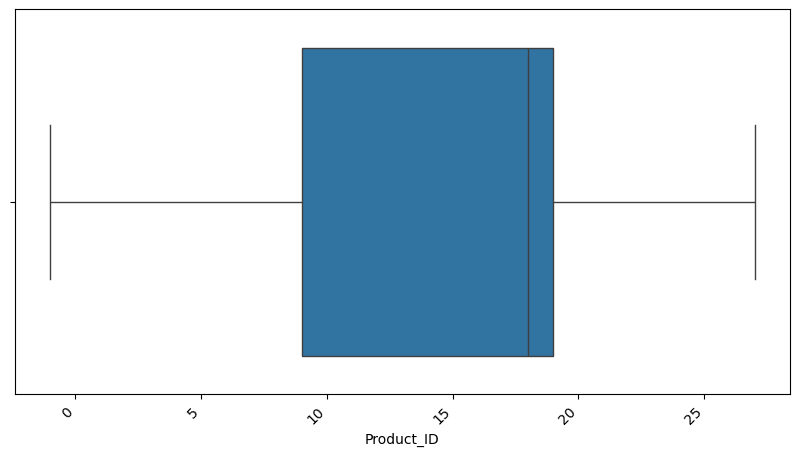

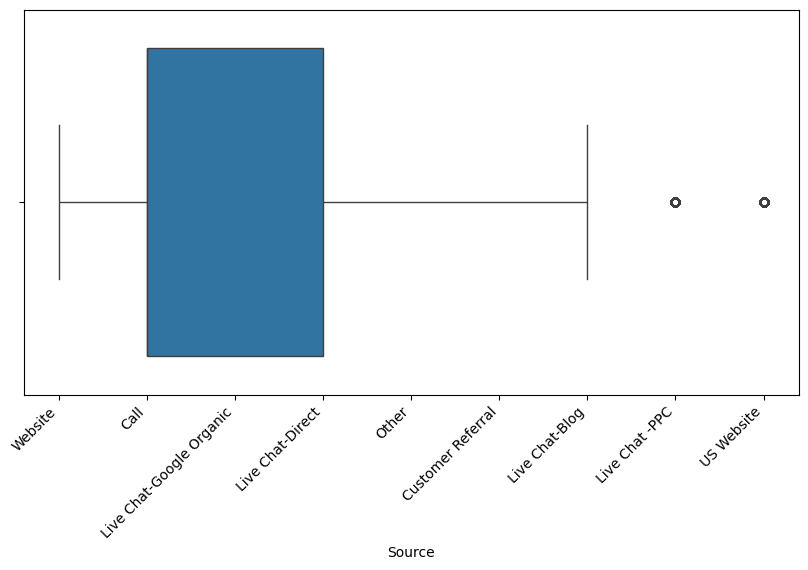

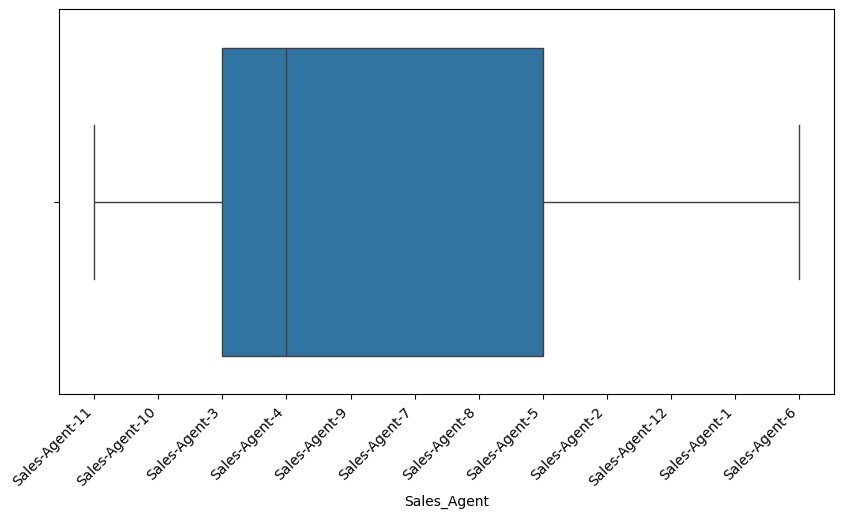

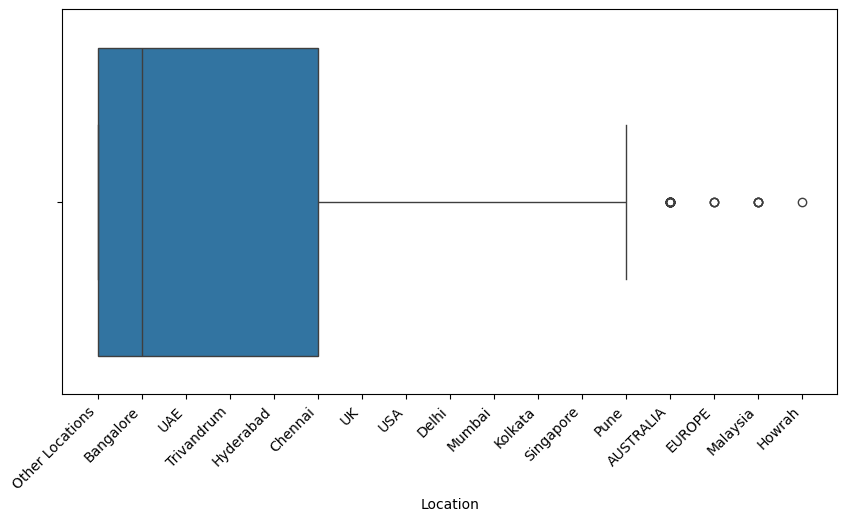

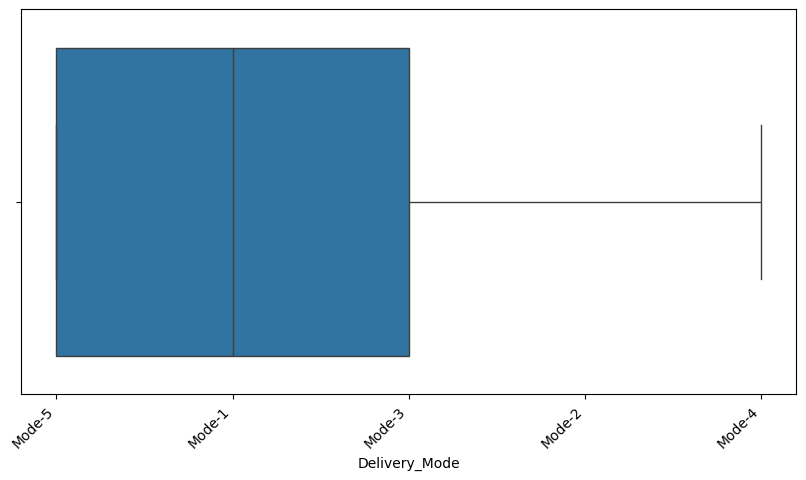

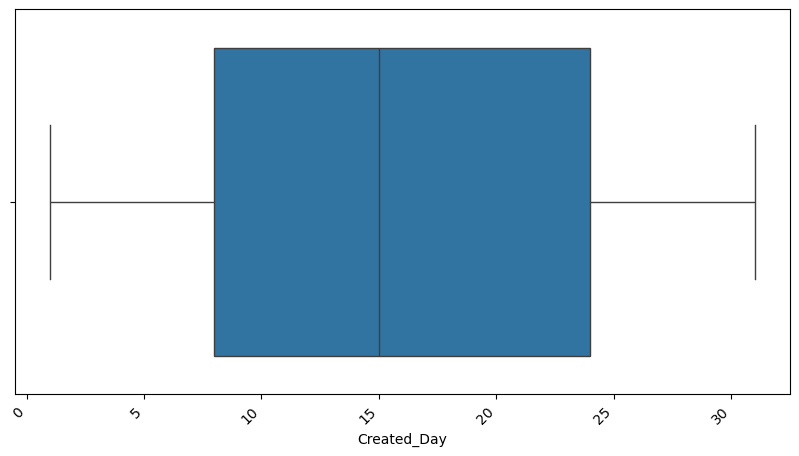

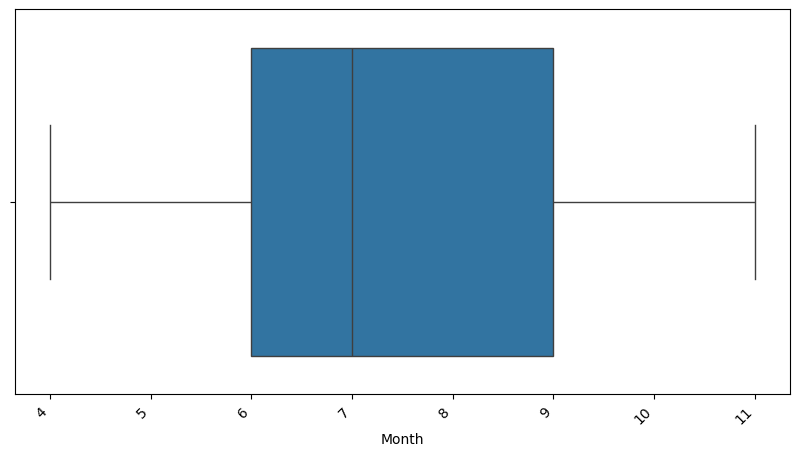

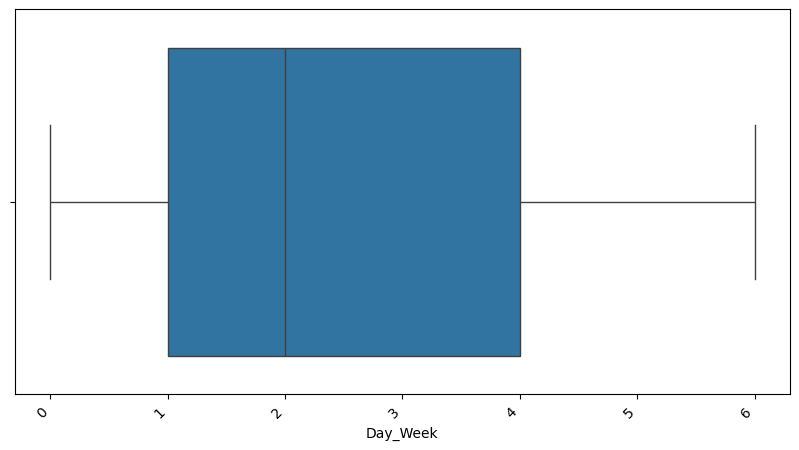

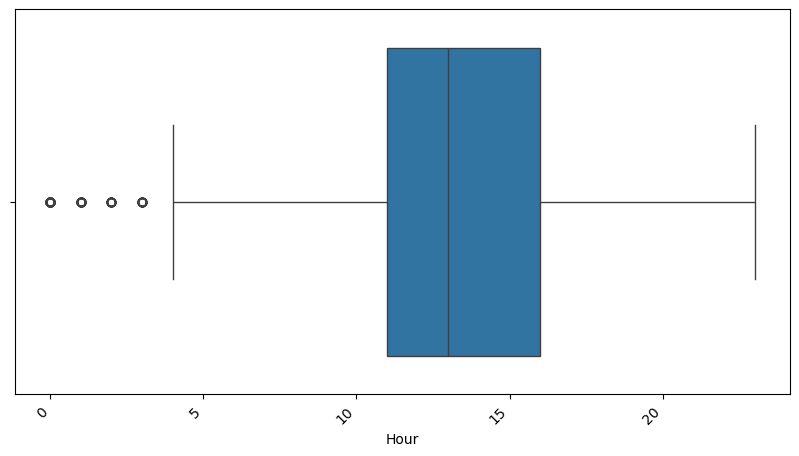

In [62]:
# checkint Outliers
num_cols = ['Product_ID','Source', 'Sales_Agent', 'Location', 'Delivery_Mode',
        'Created_Day', 'Month','Day_Week',
       'Hour']

# Checking the Outlier in the features data
for col in num_cols:
  plt.figure(figsize=(10,5))
  sns.boxplot(x=data_pre[col])
  plt.xticks(rotation=45, ha='right')
  plt.show()

# One Hot Encoding

In [63]:
# Select the columns you want to encode
features = data_pre[['Product_ID','Source', 'Sales_Agent', 'Location', 'Delivery_Mode',
                   'Created_Day', 'Month', 'Day_Week', 'Hour', 'valid_email', 'Lead_Category_enc']]

# using one hot encode
one_hot_cols = ['Product_ID','Source', 'Sales_Agent', 'Location', 'Delivery_Mode']

data_one = pd.get_dummies(features, columns=one_hot_cols, drop_first=True)

# Convert all boolean columns in the dataframe to 0/1
data_one = data_one.astype(int)

In [64]:
data_one.head()

,Created_Day,Month,Day_Week,Hour,valid_email,Lead_Category_enc,Product_ID_1.0,Product_ID_5.0,Product_ID_9.0,Product_ID_10.0,...,Location_Pune,Location_Singapore,Location_Trivandrum,Location_UAE,Location_UK,Location_USA,Delivery_Mode_Mode-2,Delivery_Mode_Mode-3,Delivery_Mode_Mode-4,Delivery_Mode_Mode-5
0,14,11,2,10,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,14,11,2,9,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,14,11,2,9,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,14,11,2,8,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,14,11,2,7,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


# Heat Map

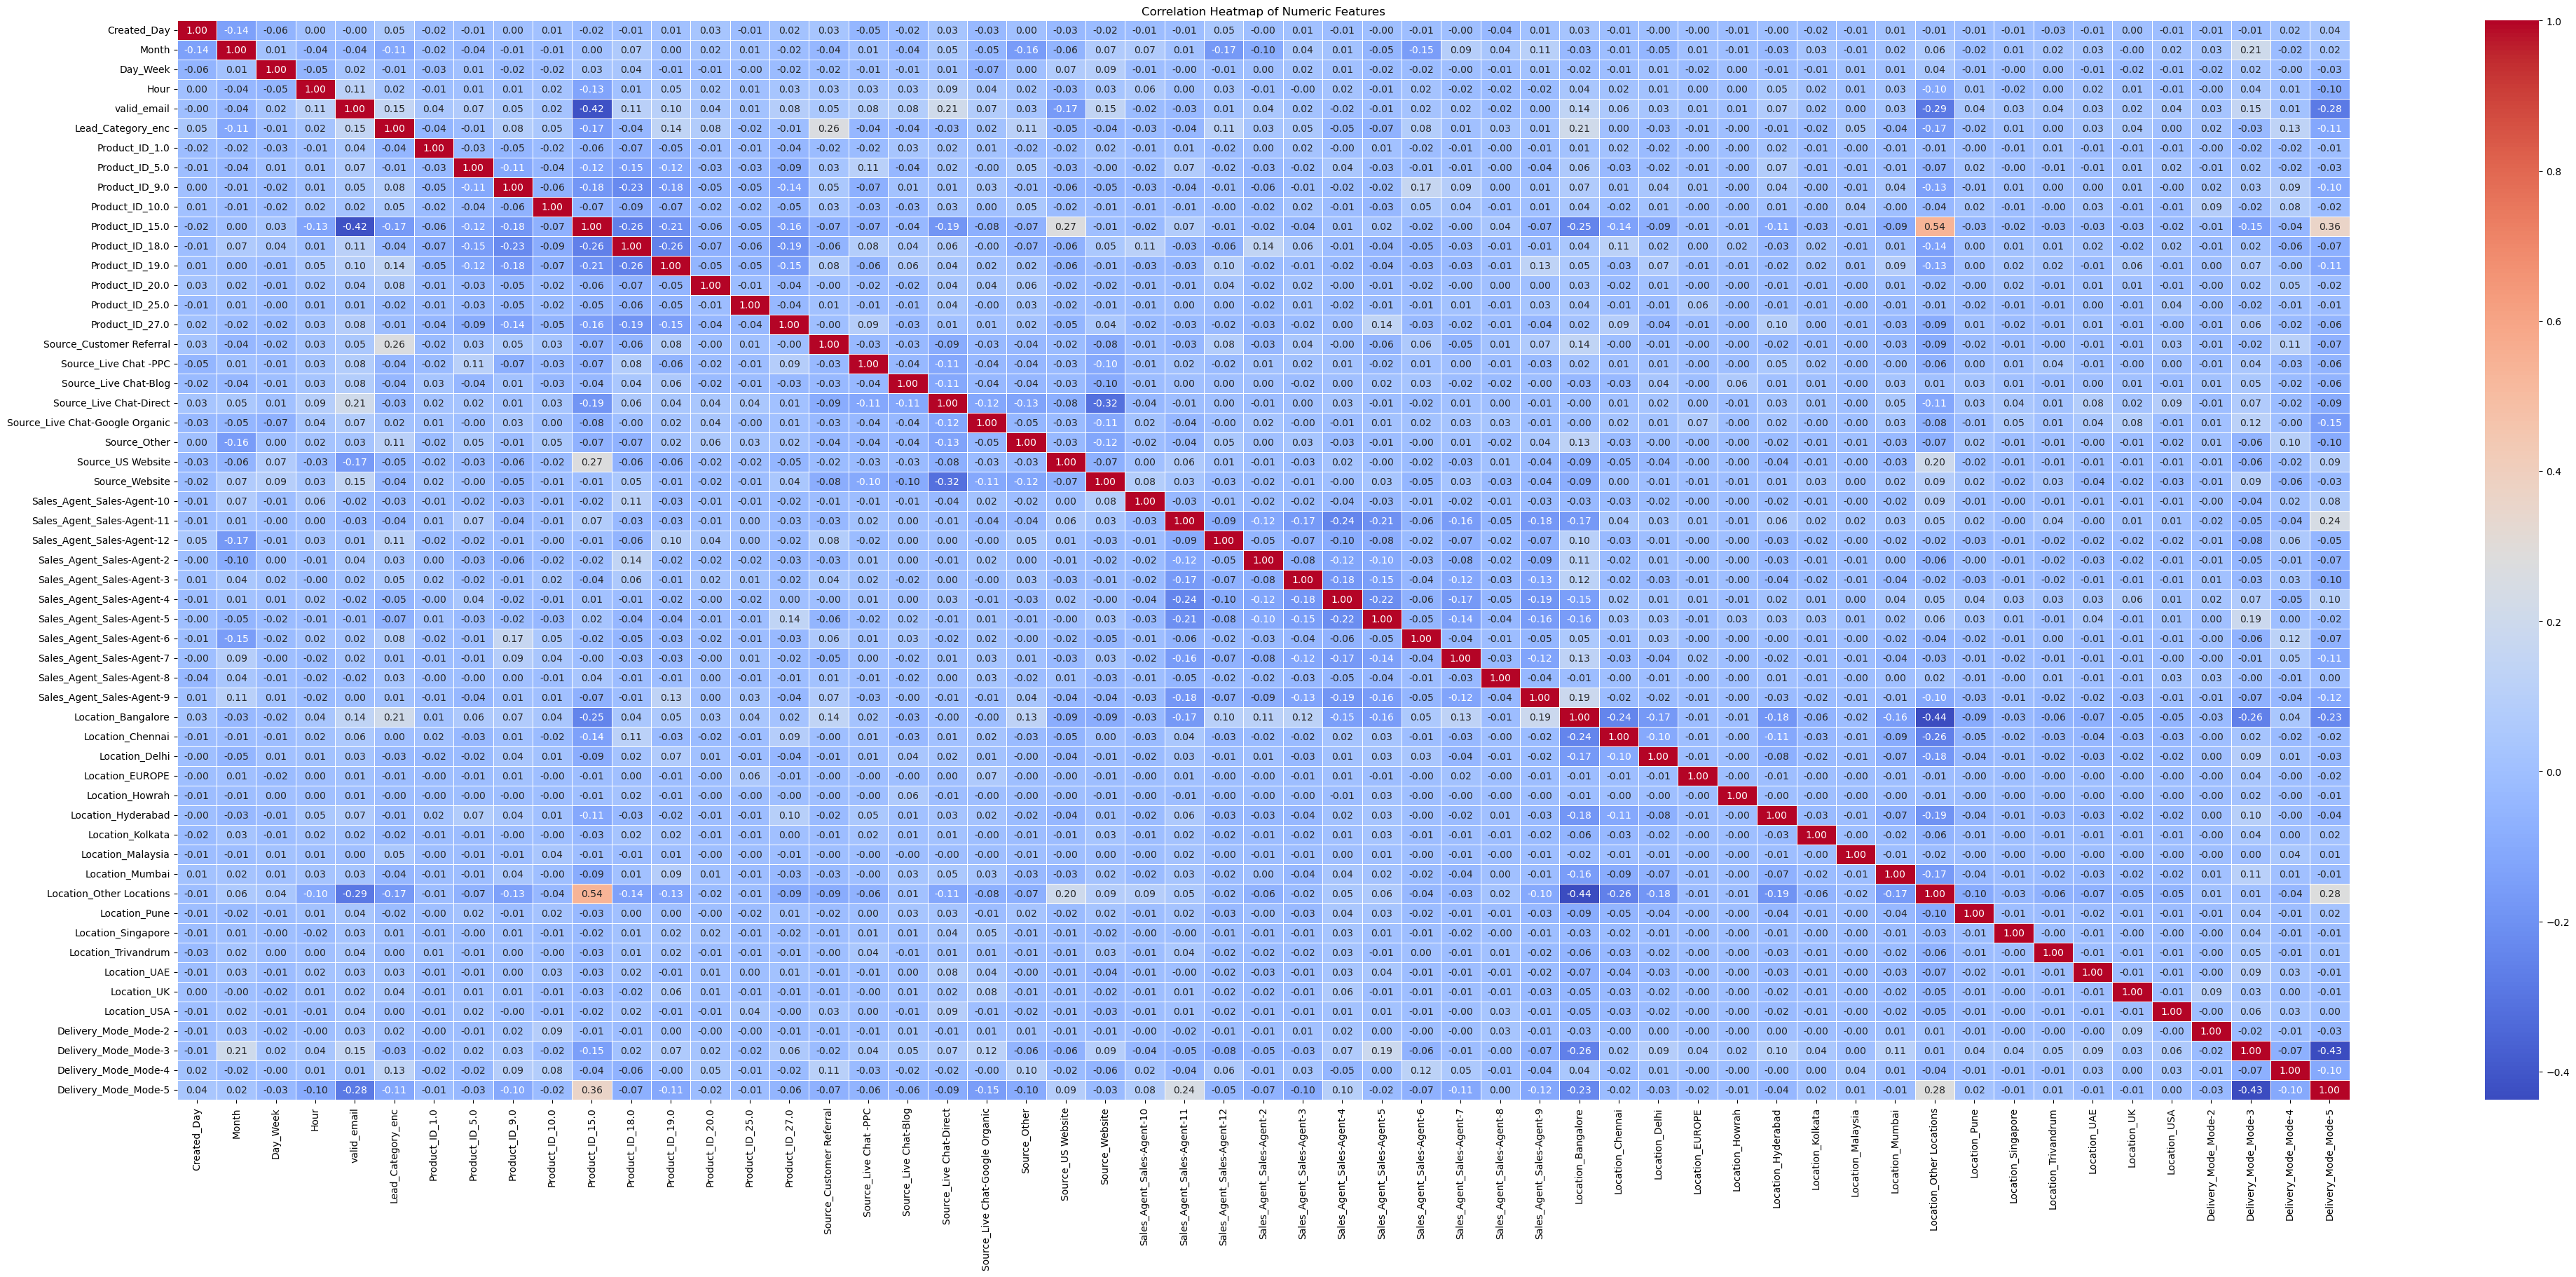

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

# keep only numeric columns
num_df = data_one.select_dtypes(include='number')

plt.figure(figsize=(50, 20))
sns.heatmap(
    num_df.corr(),
    annot=True,        # show correlation values
    fmt=".2f",         # 2 decimal places
    cmap='coolwarm',   # color palette
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

In [66]:
# Checking Co-relation with Target
import pandas as pd

corr = data_one.corr(numeric_only=True)

print(corr['Lead_Category_enc'].sort_values(ascending=False))

Lead_Category_enc                  1.000000
Source_Customer Referral           0.264318
Location_Bangalore                 0.211136
valid_email                        0.147072
Product_ID_19.0                    0.140133
Delivery_Mode_Mode-4               0.130194
Sales_Agent_Sales-Agent-12         0.114040
Source_Other                       0.111725
Product_ID_9.0                     0.079957
Sales_Agent_Sales-Agent-6          0.079500
Product_ID_20.0                    0.076598
Product_ID_10.0                    0.049007
Sales_Agent_Sales-Agent-3          0.047396
Created_Day                        0.046420
Location_Malaysia                  0.046399
Location_UK                        0.041078
Sales_Agent_Sales-Agent-8          0.031063
Sales_Agent_Sales-Agent-2          0.029058
Location_UAE                       0.028250
Hour                               0.024846
Delivery_Mode_Mode-2               0.018799
Source_Live Chat-Google Organic    0.015359
Sales_Agent_Sales-Agent-9       

# Final Dataset

In [67]:
# Creating the Final dataset to Train the Model
final_data = data_one.copy()

In [68]:
final_data.shape

(7096, 55)

In [69]:
final_data.head()

,Created_Day,Month,Day_Week,Hour,valid_email,Lead_Category_enc,Product_ID_1.0,Product_ID_5.0,Product_ID_9.0,Product_ID_10.0,...,Location_Pune,Location_Singapore,Location_Trivandrum,Location_UAE,Location_UK,Location_USA,Delivery_Mode_Mode-2,Delivery_Mode_Mode-3,Delivery_Mode_Mode-4,Delivery_Mode_Mode-5
0,14,11,2,10,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,14,11,2,9,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,14,11,2,9,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,14,11,2,8,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,14,11,2,7,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


# Model Buliding

In [70]:
from sklearn.model_selection import train_test_split

# We separate the features and target 
X = final_data.drop(['Lead_Category_enc'], axis=1)
y = final_data['Lead_Category_enc']

In [71]:
X

,Created_Day,Month,Day_Week,Hour,valid_email,Product_ID_1.0,Product_ID_5.0,Product_ID_9.0,Product_ID_10.0,Product_ID_15.0,...,Location_Pune,Location_Singapore,Location_Trivandrum,Location_UAE,Location_UK,Location_USA,Delivery_Mode_Mode-2,Delivery_Mode_Mode-3,Delivery_Mode_Mode-4,Delivery_Mode_Mode-5
0,14,11,2,10,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,14,11,2,9,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,14,11,2,9,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,14,11,2,8,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,14,11,2,7,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7417,28,4,5,9,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
7418,28,4,5,9,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
7419,28,4,5,9,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7420,28,4,5,8,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [72]:
y

0       0
1       0
2       0
3       0
4       0
       ..
7417    0
7418    0
7419    0
7420    0
7421    1
Name: Lead_Category_enc, Length: 7096, dtype: int64

In [73]:
# Splitting the data for training and testing
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42, stratify=y)


In [74]:
X_train

,Created_Day,Month,Day_Week,Hour,valid_email,Product_ID_1.0,Product_ID_5.0,Product_ID_9.0,Product_ID_10.0,Product_ID_15.0,...,Location_Pune,Location_Singapore,Location_Trivandrum,Location_UAE,Location_UK,Location_USA,Delivery_Mode_Mode-2,Delivery_Mode_Mode-3,Delivery_Mode_Mode-4,Delivery_Mode_Mode-5
1062,10,10,2,12,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5137,21,6,3,11,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011,14,9,4,9,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
5604,11,6,0,15,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
7004,8,5,1,11,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7366,30,4,0,11,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
6328,25,5,4,12,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
615,25,10,3,12,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4579,5,7,3,15,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [75]:
y_train.value_counts()

Lead_Category_enc
0    4378
1     589
Name: count, dtype: int64

In [76]:
X_train

,Created_Day,Month,Day_Week,Hour,valid_email,Product_ID_1.0,Product_ID_5.0,Product_ID_9.0,Product_ID_10.0,Product_ID_15.0,...,Location_Pune,Location_Singapore,Location_Trivandrum,Location_UAE,Location_UK,Location_USA,Delivery_Mode_Mode-2,Delivery_Mode_Mode-3,Delivery_Mode_Mode-4,Delivery_Mode_Mode-5
1062,10,10,2,12,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5137,21,6,3,11,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011,14,9,4,9,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
5604,11,6,0,15,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
7004,8,5,1,11,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7366,30,4,0,11,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
6328,25,5,4,12,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
615,25,10,3,12,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4579,5,7,3,15,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [77]:
y_test.value_counts()

Lead_Category_enc
0    1877
1     252
Name: count, dtype: int64

# Scaling the data

In [78]:
# Using Standard Scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaled_x_train = pd.DataFrame(scaler.fit_transform(X_train),columns=X_train.columns)
scaled_x_test = pd.DataFrame(scaler.transform(X_test),columns=X_test.columns)

In [79]:
scaled_x_train

,Created_Day,Month,Day_Week,Hour,valid_email,Product_ID_1.0,Product_ID_5.0,Product_ID_9.0,Product_ID_10.0,Product_ID_15.0,...,Location_Pune,Location_Singapore,Location_Trivandrum,Location_UAE,Location_UK,Location_USA,Delivery_Mode_Mode-2,Delivery_Mode_Mode-3,Delivery_Mode_Mode-4,Delivery_Mode_Mode-5
0,-0.621491,1.333985,-0.212265,-0.327171,-1.427558,-0.116046,-0.267636,-0.400304,-0.154637,-0.462099,...,-0.141871,-0.049212,-0.087804,-0.098783,-0.077952,-0.079249,-0.040165,-0.555102,-0.139639,-0.782059
1,0.590848,-0.791746,0.330919,-0.570189,0.700497,-0.116046,-0.267636,-0.400304,-0.154637,-0.462099,...,-0.141871,-0.049212,-0.087804,-0.098783,-0.077952,-0.079249,-0.040165,-0.555102,-0.139639,-0.782059
2,-0.180640,0.802552,0.874103,-1.056224,-1.427558,-0.116046,-0.267636,-0.400304,-0.154637,-0.462099,...,-0.141871,-0.049212,-0.087804,-0.098783,-0.077952,-0.079249,-0.040165,1.801471,-0.139639,-0.782059
3,-0.511278,-0.791746,-1.298633,0.401882,0.700497,-0.116046,-0.267636,2.498104,-0.154637,-0.462099,...,-0.141871,-0.049212,-0.087804,-0.098783,-0.077952,-0.079249,-0.040165,-0.555102,-0.139639,-0.782059
4,-0.841916,-1.323179,-0.755449,-0.570189,-1.427558,-0.116046,-0.267636,2.498104,-0.154637,-0.462099,...,-0.141871,-0.049212,-0.087804,-0.098783,-0.077952,-0.079249,-0.040165,-0.555102,-0.139639,-0.782059
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4962,1.582761,-1.854611,-1.298633,-0.570189,0.700497,-0.116046,-0.267636,2.498104,-0.154637,-0.462099,...,-0.141871,-0.049212,-0.087804,-0.098783,-0.077952,-0.079249,-0.040165,-0.555102,-0.139639,-0.782059
4963,1.031698,-1.323179,0.874103,-0.327171,0.700497,-0.116046,-0.267636,-0.400304,-0.154637,-0.462099,...,-0.141871,-0.049212,-0.087804,-0.098783,-0.077952,-0.079249,-0.040165,-0.555102,-0.139639,1.278676
4964,1.031698,1.333985,0.330919,-0.327171,-1.427558,-0.116046,-0.267636,-0.400304,-0.154637,-0.462099,...,-0.141871,-0.049212,-0.087804,-0.098783,-0.077952,-0.079249,-0.040165,-0.555102,-0.139639,1.278676
4965,-1.172554,-0.260313,0.330919,0.401882,-1.427558,-0.116046,-0.267636,-0.400304,-0.154637,-0.462099,...,-0.141871,-0.049212,-0.087804,-0.098783,-0.077952,-0.079249,-0.040165,-0.555102,-0.139639,-0.782059


In [80]:
scaled_x_test

,Created_Day,Month,Day_Week,Hour,valid_email,Product_ID_1.0,Product_ID_5.0,Product_ID_9.0,Product_ID_10.0,Product_ID_15.0,...,Location_Pune,Location_Singapore,Location_Trivandrum,Location_UAE,Location_UK,Location_USA,Delivery_Mode_Mode-2,Delivery_Mode_Mode-3,Delivery_Mode_Mode-4,Delivery_Mode_Mode-5
0,-1.062341,1.333985,1.417287,0.401882,0.700497,-0.116046,-0.267636,-0.400304,-0.154637,-0.462099,...,-0.141871,-0.049212,-0.087804,-0.098783,-0.077952,-0.079249,-0.040165,1.801471,-0.139639,-0.782059
1,0.590848,0.271119,-0.755449,0.644899,0.700497,-0.116046,-0.267636,-0.400304,-0.154637,2.164039,...,-0.141871,-0.049212,-0.087804,-0.098783,-0.077952,12.618471,-0.040165,-0.555102,-0.139639,1.278676
2,-0.511278,1.333985,0.330919,-0.570189,0.700497,-0.116046,3.736421,-0.400304,-0.154637,-0.462099,...,-0.141871,-0.049212,-0.087804,-0.098783,-0.077952,-0.079249,-0.040165,1.801471,-0.139639,-0.782059
3,-1.282766,0.802552,-0.755449,-0.570189,-1.427558,-0.116046,-0.267636,-0.400304,-0.154637,-0.462099,...,-0.141871,-0.049212,-0.087804,-0.098783,-0.077952,-0.079249,-0.040165,1.801471,-0.139639,-0.782059
4,-1.062341,0.802552,0.330919,-0.813206,-1.427558,-0.116046,-0.267636,-0.400304,-0.154637,2.164039,...,-0.141871,-0.049212,-0.087804,-0.098783,-0.077952,-0.079249,-0.040165,-0.555102,-0.139639,1.278676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2124,1.252123,0.271119,-1.298633,-0.570189,-1.427558,-0.116046,-0.267636,-0.400304,-0.154637,-0.462099,...,-0.141871,-0.049212,-0.087804,-0.098783,-0.077952,-0.079249,-0.040165,-0.555102,-0.139639,1.278676
2125,-0.731703,0.271119,0.330919,2.103005,0.700497,-0.116046,-0.267636,-0.400304,6.466759,-0.462099,...,-0.141871,-0.049212,-0.087804,-0.098783,-0.077952,-0.079249,-0.040165,-0.555102,-0.139639,1.278676
2126,1.472549,-1.323179,-0.755449,-0.327171,0.700497,-0.116046,-0.267636,2.498104,-0.154637,-0.462099,...,-0.141871,-0.049212,11.389053,-0.098783,-0.077952,-0.079249,-0.040165,-0.555102,-0.139639,-0.782059
2127,0.590848,-1.323179,-1.298633,-0.813206,0.700497,-0.116046,-0.267636,-0.400304,-0.154637,-0.462099,...,-0.141871,-0.049212,-0.087804,-0.098783,-0.077952,-0.079249,-0.040165,-0.555102,-0.139639,-0.782059


# SMOTE

In [81]:
#.Using smote to balance the imbalance data
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(scaled_x_train, y_train)

In [82]:
X_train_sm 

,Created_Day,Month,Day_Week,Hour,valid_email,Product_ID_1.0,Product_ID_5.0,Product_ID_9.0,Product_ID_10.0,Product_ID_15.0,...,Location_Pune,Location_Singapore,Location_Trivandrum,Location_UAE,Location_UK,Location_USA,Delivery_Mode_Mode-2,Delivery_Mode_Mode-3,Delivery_Mode_Mode-4,Delivery_Mode_Mode-5
0,-0.621491,1.333985,-0.212265,-0.327171,-1.427558,-0.116046,-0.267636,-0.400304,-0.154637,-0.462099,...,-0.141871,-0.049212,-0.087804,-0.098783,-0.077952,-0.079249,-0.040165,-0.555102,-0.139639,-0.782059
1,0.590848,-0.791746,0.330919,-0.570189,0.700497,-0.116046,-0.267636,-0.400304,-0.154637,-0.462099,...,-0.141871,-0.049212,-0.087804,-0.098783,-0.077952,-0.079249,-0.040165,-0.555102,-0.139639,-0.782059
2,-0.180640,0.802552,0.874103,-1.056224,-1.427558,-0.116046,-0.267636,-0.400304,-0.154637,-0.462099,...,-0.141871,-0.049212,-0.087804,-0.098783,-0.077952,-0.079249,-0.040165,1.801471,-0.139639,-0.782059
3,-0.511278,-0.791746,-1.298633,0.401882,0.700497,-0.116046,-0.267636,2.498104,-0.154637,-0.462099,...,-0.141871,-0.049212,-0.087804,-0.098783,-0.077952,-0.079249,-0.040165,-0.555102,-0.139639,-0.782059
4,-0.841916,-1.323179,-0.755449,-0.570189,-1.427558,-0.116046,-0.267636,2.498104,-0.154637,-0.462099,...,-0.141871,-0.049212,-0.087804,-0.098783,-0.077952,-0.079249,-0.040165,-0.555102,-0.139639,-0.782059
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8751,1.582761,-0.010292,-0.531984,0.573631,0.700497,-0.116046,-0.267636,-0.400304,6.466759,-0.462099,...,-0.141871,-0.049212,-0.087804,-0.098783,-0.077952,-0.079249,-0.040165,-0.555102,-0.139639,0.187448
8752,-0.863233,0.516789,0.435979,0.430550,0.700497,-0.116046,-0.267636,-0.400304,-0.154637,-0.462099,...,-0.141871,-0.049212,-0.087804,-0.098783,-0.077952,-0.079249,-0.040165,-0.555102,-0.139639,-0.782059
8753,-0.169048,-0.237954,1.383006,-0.549739,0.700497,-0.116046,-0.267636,-0.400304,-0.154637,-0.462099,...,-0.141871,-0.049212,-0.087804,-0.098783,-0.077952,-0.079249,-0.040165,-0.555102,-0.139639,1.235325
8754,1.135312,0.181564,-0.604900,0.510189,0.700497,-0.116046,-0.267636,-0.400304,-0.154637,-0.462099,...,-0.141871,-0.049212,-0.087804,-0.098783,-0.077952,-0.079249,-0.040165,1.148322,-0.139639,-0.782059


In [83]:
y_train_sm.value_counts()

Lead_Category_enc
0    4378
1    4378
Name: count, dtype: int64

# Logistic Regression Model

In [84]:
# Import Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# Using Logistic Regression 
log_reg= LogisticRegression( 
        C=1.0,
        solver='liblinear',
        class_weight='balanced',
        max_iter=1000,
        random_state=42)

# training the model
log_reg.fit(X_train_sm, y_train_sm) 

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42,
                   solver='liblinear')

In [85]:
# Predicting the model
y_pred_lr = log_reg.predict(scaled_x_test)
y_prob_lr = log_reg.predict_proba(scaled_x_test)[:,1]

In [86]:
# Evaluation the Model
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nROC-AUC:\n", roc_auc_score(y_test, y_prob_lr))

Accuracy: 0.737905119774542

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.74      0.83      1877
           1       0.27      0.70      0.39       252

    accuracy                           0.74      2129
   macro avg       0.61      0.72      0.61      2129
weighted avg       0.87      0.74      0.78      2129


Confusion Matrix:
 [[1395  482]
 [  76  176]]

ROC-AUC:
 0.8172964710657838


# KNN Model

In [87]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier()

knn_clf.fit(X_train_sm, y_train_sm)

KNeighborsClassifier()

In [88]:
# Predicting the Model
y_pred_knn = knn_clf.predict(scaled_x_test)
y_prob_knn = knn_clf.predict_proba(scaled_x_test)[:,1]

In [89]:
# Evaluation the Model
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("\nROC-AUC:\n", roc_auc_score(y_test, y_prob_knn))

Accuracy: 0.7191169563175199

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.74      0.82      1877
           1       0.23      0.59      0.33       252

    accuracy                           0.72      2129
   macro avg       0.58      0.66      0.58      2129
weighted avg       0.85      0.72      0.76      2129


Confusion Matrix:
 [[1382  495]
 [ 103  149]]

ROC-AUC:
 0.7104347954774166


# Using Smote for Tree Based Model

In [90]:
# SMOTE is available but not applied in this notebook by default.
# If you want to address class imbalance, uncomment the lines below and rerun.
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


In [91]:
X_train_smote 


,Created_Day,Month,Day_Week,Hour,valid_email,Product_ID_1.0,Product_ID_5.0,Product_ID_9.0,Product_ID_10.0,Product_ID_15.0,...,Location_Pune,Location_Singapore,Location_Trivandrum,Location_UAE,Location_UK,Location_USA,Delivery_Mode_Mode-2,Delivery_Mode_Mode-3,Delivery_Mode_Mode-4,Delivery_Mode_Mode-5
0,10,10,2,12,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,21,6,3,11,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,14,9,4,9,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,11,6,0,15,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,5,1,11,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8751,28,8,3,12,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8752,7,8,4,16,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8753,14,7,5,11,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8754,31,10,2,12,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [92]:
y_train_smote.value_counts()


Lead_Category_enc
0    4378
1    4378
Name: count, dtype: int64

# Decision Tree Model

In [93]:


# Import libraries
from sklearn.tree import DecisionTreeClassifier

# Decision Tree Classifier 
dt_clf = DecisionTreeClassifier()

# Training the model
dt_clf.fit(X_train_smote, y_train_smote)

DecisionTreeClassifier()

In [94]:
# Predictions
y_pred_dt= dt_clf.predict(X_test)
y_prob_dt = dt_clf.predict_proba(X_test)[:,1]

In [95]:
# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nROC-AUC:\n", roc_auc_score(y_test, y_prob_dt))

Accuracy: 0.7909816815406294
              precision    recall  f1-score   support

           0       0.90      0.85      0.88      1877
           1       0.23      0.32      0.27       252

    accuracy                           0.79      2129
   macro avg       0.57      0.59      0.57      2129
weighted avg       0.82      0.79      0.81      2129


Confusion Matrix:
 [[1603  274]
 [ 171   81]]

ROC-AUC:
 0.5871831950681178


# Rando Forest Model

In [96]:
# Import libraries
from sklearn.ensemble import RandomForestClassifier

# Random Forest Classifier 
rf_clf = RandomForestClassifier(
     n_estimators=100,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

# Training the model
rf_clf.fit(X_train_smote, y_train_smote)

RandomForestClassifier(class_weight='balanced', max_depth=5, min_samples_leaf=5,
                       min_samples_split=5, n_jobs=-1, random_state=42)

In [97]:
# Predictions
y_pred_rf = rf_clf.predict(X_test)
y_prob_rf = rf_clf.predict_proba(X_test)[:,1]

In [98]:
# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nROC-AUC:\n", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.7703147017379052
              precision    recall  f1-score   support

           0       0.93      0.80      0.86      1877
           1       0.26      0.52      0.35       252

    accuracy                           0.77      2129
   macro avg       0.59      0.66      0.60      2129
weighted avg       0.85      0.77      0.80      2129


Confusion Matrix:
 [[1510  367]
 [ 122  130]]

ROC-AUC:
 0.7583921066206628


# XG Boost Model

In [99]:
# Using XG Boost Model
from xgboost import XGBClassifier


xgb = XGBClassifier(
      n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=1,
        reg_alpha=0.5,
        reg_lambda=1.0,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42
)


# Training the Model
xgb.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [100]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

In [101]:
# Evaluate the model (default XGBoost)
y_pred_xgb_default = y_pred_xgb
y_prob_xgb_default = y_prob_xgb
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_default))
print(classification_report(y_test, y_pred_xgb_default))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb_default))
print("\nROC-AUC:\n", roc_auc_score(y_test, y_prob_xgb_default))

Accuracy: 0.8727101925786754
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      1877
           1       0.44      0.30      0.36       252

    accuracy                           0.87      2129
   macro avg       0.68      0.63      0.64      2129
weighted avg       0.85      0.87      0.86      2129


Confusion Matrix:
 [[1782   95]
 [ 176   76]]

ROC-AUC:
 0.8060132683867367


# GB Model 

In [102]:
from sklearn.ensemble import GradientBoostingClassifier

# Gradient Boosting model
gb_clf = GradientBoostingClassifier(
    n_estimators=300,    
    learning_rate=0.05,   
    max_depth=3,          
    min_samples_split=50, 
    min_samples_leaf=20,  
    subsample=0.8,       
    random_state=42
)

# Train on SMOTE-balanced training data (as in your tree models)
gb_clf.fit(X_train_smote, y_train_smote)

GradientBoostingClassifier(learning_rate=0.05, min_samples_leaf=20,
                           min_samples_split=50, n_estimators=300,
                           random_state=42, subsample=0.8)

In [103]:
# Predictions
y_pred_gb = gb_clf.predict(X_test)
y_prob_gb = gb_clf.predict_proba(X_test)[:, 1]

In [104]:
# Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred_gb))
print("\nClassification Report")
print(classification_report(y_test, y_pred_gb))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_gb))
print("ROC-AUC :", roc_auc_score(y_test, y_prob_gb))

Accuracy : 0.8670737435415689

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.94      0.93      1877
           1       0.42      0.33      0.37       252

    accuracy                           0.87      2129
   macro avg       0.67      0.63      0.65      2129
weighted avg       0.85      0.87      0.86      2129

Confusion Matrix
[[1763  114]
 [ 169   83]]
ROC-AUC : 0.8028103356419818


# Hyper Tunning The GB Model

In [105]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Base model
gb_base = GradientBoostingClassifier(random_state=42)

# Parameter grid to tune
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_split": [20, 50, 100],
    "min_samples_leaf": [10, 20, 50],
    "subsample": [0.8, 1.0]
}

# Stratified CV (important for imbalanced LeadCategory) [file:1]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV with ROC-AUC as scoring
gb_grid = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

# Fit on SMOTE-balanced training data (as you did for tree models) [file:1]
gb_grid.fit(X_train_smote, y_train_smote)

print("Best parameters:", gb_grid.best_params_)
print("Best CV ROC-AUC:", gb_grid.best_score_)

# Best model
best_gb = gb_grid.best_estimator_

Fitting 5 folds for each of 486 candidates, totalling 2430 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 20, 'min_samples_split': 20, 'n_estimators': 300, 'subsample': 0.8}
Best CV ROC-AUC: 0.9249996312781811


In [106]:
# Evaluate on original test set
y_pred_gbm = best_gb.predict(X_test)
y_prob_gbm = best_gb.predict_proba(X_test)[:, 1]

In [107]:
print("\nTest Accuracy :", accuracy_score(y_test, y_pred_gbm))
print("Test ROC-AUC  :", roc_auc_score(y_test, y_prob_gbm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_gbm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gbm))


Test Accuracy : 0.8759981211836543
Test ROC-AUC  : 0.793601111195677

Confusion Matrix:
 [[1791   86]
 [ 178   74]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93      1877
           1       0.46      0.29      0.36       252

    accuracy                           0.88      2129
   macro avg       0.69      0.62      0.65      2129
weighted avg       0.86      0.88      0.86      2129



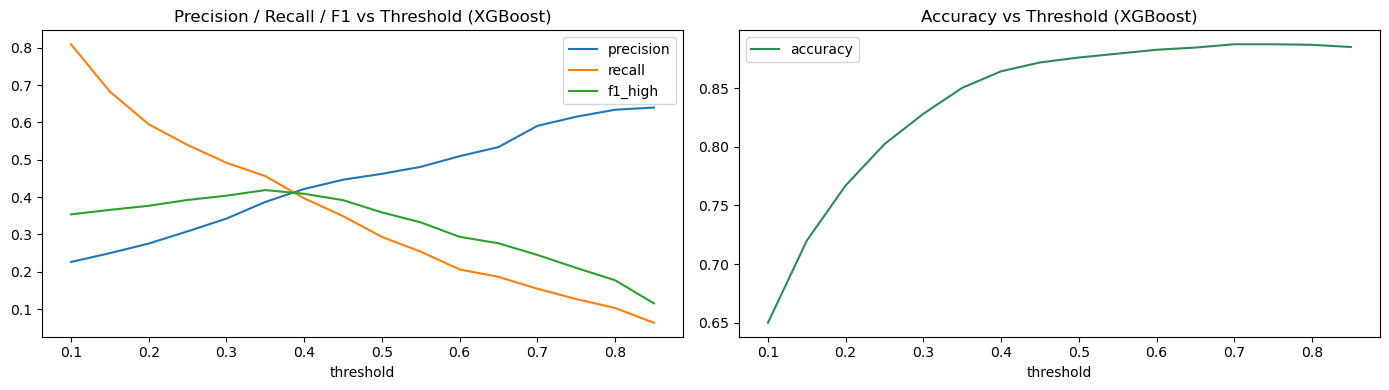


Optimal threshold (max F1 – High Potential): 0.35
                precision    recall  f1-score   support

 Low Potential       0.93      0.90      0.91      1877
High Potential       0.39      0.46      0.42       252

      accuracy                           0.85      2129
     macro avg       0.66      0.68      0.67      2129
  weighted avg       0.86      0.85      0.86      2129



In [113]:
# Using threshold to improve the Model
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,classification_report)

thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for t in thresholds:
    preds = (y_prob_gbm >= t).astype(int)
    results.append({
        'threshold': round(float(t), 2),
        'accuracy':  accuracy_score(y_test, preds),
        'f1_high':   f1_score(y_test, preds, pos_label=1, zero_division=0),
        'precision': precision_score(y_test, preds, pos_label=1, zero_division=0),
        'recall':    recall_score(y_test, preds, pos_label=1, zero_division=0),
    })

thresh_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

thresh_df.plot(
    x='threshold',
    y=['precision', 'recall', 'f1_high'],
    ax=axes[0],
    title='Precision / Recall / F1 vs Threshold (XGBoost)'
)

thresh_df.plot(
    x='threshold',
    y='accuracy',
    ax=axes[1],
    title='Accuracy vs Threshold (XGBoost)',
    color='seagreen'
)

plt.tight_layout()
plt.show()

best_thresh_xgb = thresh_df.loc[thresh_df['f1_high'].idxmax(), 'threshold']
print(f"\nOptimal threshold (max F1 – High Potential): {best_thresh_xgb:.2f}")

y_pred_xgb_thresh = (y_prob_gbm >= best_thresh_xgb).astype(int)

print(classification_report( y_test, y_pred_xgb_thresh, target_names=['Low Potential', 'High Potential']))

## Feature Importance

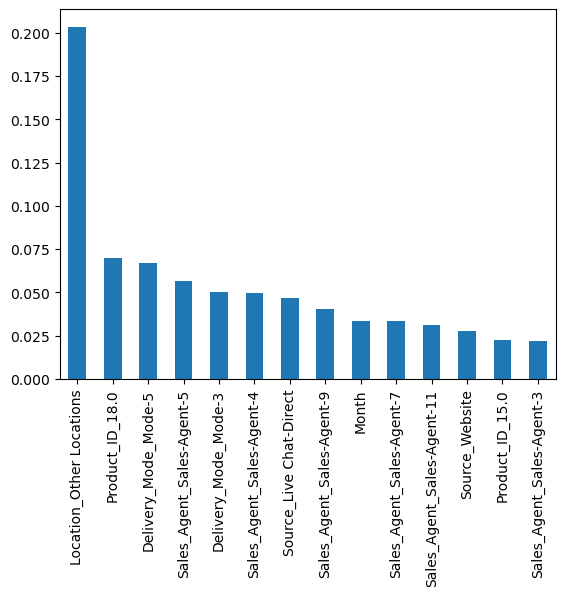

In [121]:
importances = gb_clf.feature_importances_

feat_imp = pd.Series(importances, index=X.columns)
feat_imp.sort_values(ascending=False).head(14).plot(kind='bar')
plt.show()

# Best Model

In [123]:


# Define models
models = {
    "Logistic Regression": log_reg,      
    "KNN": knn_clf,                      
    "Decision Tree": dt_clf,             
    "Random Forest": rf_clf,            
    "XGBoost": xgb,                  
    "Gradient Boosting": gb_clf      
}

results = []

for name, model in models.items():
 
    
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = None
    
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1)
    rec  = recall_score(y_test, y_pred, pos_label=1)
    f1   = f1_score(y_test, y_pred, pos_label=1)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision (High)": prec,
        "Recall (High)": rec,
        "F1 (High)": f1,
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(results).sort_values(by="F1 (High)", ascending=False)
results_df

,Model,Accuracy,Precision (High),Recall (High),F1 (High),ROC-AUC
5,Gradient Boosting,0.867074,0.421320,0.329365,0.369710,0.802810
4,XGBoost,0.872710,0.444444,0.301587,0.359338,0.806013
3,Random Forest,0.770315,0.261569,0.515873,0.347130,0.758392
2,Decision Tree,0.790982,0.228169,0.321429,0.266886,0.587183
0,Logistic Regression,0.829967,0.222222,0.174603,0.195556,0.673012
1,KNN,0.860498,0.105263,0.023810,0.038835,0.510068


In [124]:
print("Best model by F1 for High Potential:")
best_row = results_df.iloc[0]
best_row

Best model by F1 for High Potential:


Model               Gradient Boosting
Accuracy                     0.867074
Precision (High)              0.42132
Recall (High)                0.329365
F1 (High)                     0.36971
ROC-AUC                       0.80281
Name: 5, dtype: object

# Conclusion 

## Challenges Faced in the Data

### High‑cardinality categorical features

Columns like Source, Sales_Agent, Location, and Delivery_Mode had many unique categories.

Challenge: Direct one‑hot encoding would create a very wide sparse matrix and increase risk of overfitting.

### Unstructured contact and datetime fields

Mobile numbers and email IDs were embedded as raw strings, and Created was a string timestamp.

Challenge: Hard to derive useful numeric patterns (validity, time‑of‑day, day‑of‑week) for modeling.

### Missing and invalid values

Product_ID, Location, Delivery_Mode, and contact fields contained missing or invalid entries (e.g., #VALUE!, masked mobiles).

Challenge: Needed consistent cleaning to avoid information loss or data leakage.

### Imbalanced lead categories

The derived target Lead_Category_enc (High vs Low Potential) was imbalanced, with Low Potential dominating.

Challenge: Vanilla models would be biased towards the majority class, inflating accuracy but hurting recall for High Potential leads.

### Large number of derived dummy variables

After encoding, the feature space expanded to over 50 columns, including many one‑hot encoded Product_ID, Location, and Delivery_Mode indicators.

Challenge: Required careful model choice and regularization to handle dimensionality.

## Techniques Used & Reasons

### Data cleaning and preparation

Parsed Created into Created_Day, Month, Day_Week, and Hour to capture temporal patterns.

Built valid_email and related indicators to summarize contact quality while handling masked/invalid entries.

Reason: Turned messy raw strings into structured numeric features suitable for ML.

### Feature engineering

Engineered calendar/time features (day, month, weekday, hour) to learn when high‑quality leads tend to arrive.

Kept a compact set of behaviorally meaningful variables: product type, source, sales agent, location, delivery mode, and contact validity.

Reason: Encoded business intuition (who, where, when, and how the lead came) directly into the feature set.

### Encoding strategy

Applied one‑hot encoding to categorical variables like Product_ID, Source, Location, and Delivery_Mode after grouping rare categories (e.g., “Other Locations”).

Reason: Allowed tree‑based models to split cleanly on important categories while controlling feature explosion.

### Handling class imbalance

Used class_weight='balanced' for models such as Logistic Regression and Random Forest.

Reason: Penalized misclassification of the minority High Potential class more heavily, improving its recall.

## Model Selection and Evaluation

### Model experimentation

Trained multiple algorithms: Logistic Regression, k‑NN, Decision Tree, Random Forest, Gradient Boosting, and XGBoost on the processed dataset.

Reason: Compared simple linear baselines with more powerful non‑linear, ensemble methods suitable for high‑dimensional categorical data.

### Evaluation approach

Evaluated models using classification metrics (such as accuracy and class‑wise performance) and inspected feature importances for tree‑based models.

Reason: Ensured the chosen model balanced overall performance with business interpretability on what drives lead quality.

## Key Insights

Tree‑based ensemble models (Random Forest, Gradient Boosting, XGBoost) captured non‑linear interactions between product, source, location, and time features better than simple linear models.

Engineered temporal and contact‑quality features (e.g., Hour, Day_Week, valid_email) added significant predictive power for distinguishing High vs Low Potential leads.

The encoding and class‑balancing strategy were critical: naive encoding or ignoring imbalance would have led to high apparent accuracy but poor identification of truly high‑potential leads.

# Future Insights

### Richer features from raw data
* Add more behavioral/business features, such as lead response time, number of follow‑ups, marketing campaign info, or historical conversion rates by agent/source to improve signal beyond current columns.

### Better handling of class imbalance
* Experiment with SMOTE/ADASYN, undersampling, or cost‑sensitive/focal loss approaches in addition to class_weight='balanced' to further boost recall on High Potential leads.

### More systematic model selection
* Run proper cross‑validation with a clear metric (e.g., F1 for High Potential, ROC‑AUC) and compare models in a table to justify the final choice more rigorously.

### Threshold tuning and business KPIs
* Optimize the classification threshold based on business costs (missed high‑value lead vs wasted effort) and report business‑oriented metrics like uplift in conversion or leads per agent.

### Model explainability for sales team
* Use SHAP/feature importance plots per prediction so sales can see which factors (source, hour, location, email validity) drive a lead’s score, increasing trust and adoption.

### Robustness and monitoring in production
* Plan for deployment with monitoring of data drift, class distribution changes, and periodic retraining schedules to keep performance stable over time.

### Extend to ranking/lead scoring
* Move from binary classification to a continuous lead score (0–1 or 0–100) and evaluate ranking metrics (e.g., top‑k precision), which align better with real‑world lead prioritization.